qRT-PCR and PRO-seq are showing fairly different results, particularly when it comes to early response PRO-seq genes. 
Therefore, I want to see how PRO-seq and RNA-seq compare:
1. Are the genes generally responding the same?
	1. Is there better alliance if I ignore the early response genes?
2. Do we see a trend where most genes are early responding in RNA-seq like in PRO-seq?
3. Does it also look like a bomb goes off for RNA-seq?

In [150]:
library(ComplexHeatmap)
library(clusterProfiler)
library(org.Hs.eg.db)
library(data.table)

Warning message:
"package 'data.table' was built under R version 4.4.1"

Adjuntando el paquete: 'data.table'


The following object is masked from 'package:IRanges':

    shift


The following objects are masked from 'package:S4Vectors':

    first, second




## 0. Read in significance calls

In [1]:
# DESeq2 for RNA-seq (from Arnav)
rna_2hr = read.table("../results/DESeq2/res_Gene_RNAseq_WSP2h_vs_Veh_par_rat_Wd_GeneHK.txt", header=TRUE, sep=",")
rna_2hr$Gene <- rownames(rna_2hr)
rna_2hr[1:4,]
rna_4hr = read.table("../results/DESeq2/res_Gene_RNAseq_WSP4h_vs_Veh_par_rat_Wd_GeneHK.txt", header=TRUE, sep=",")
rna_4hr$Gene <- rownames(rna_4hr)
rna_4hr[1:4,]


# convert for easier comparison
colnames(rna_2hr) <- c("baseMean", "RNA_2hr_L2FC", "lfcSE", "stat", "pvalue", "RNA_2hr_padj", "Gene")
colnames(rna_4hr) <- c("baseMean", "RNA_4hr_L2FC", "lfcSE", "stat", "pvalue", "RNA_4hr_padj", "Gene")

rna <- merge(rna_2hr[,c("Gene", "RNA_2hr_L2FC", "RNA_2hr_padj")], rna_4hr[,c("Gene", "RNA_4hr_L2FC", "RNA_4hr_padj")], by="Gene", all=TRUE)

rna[1:2,]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TUFT1,5380.496,1.360850,0.02622962,51.88218,0,0,TUFT1
IL24,1062.889,3.472787,0.07699914,45.10163,0,0,IL24
ATF3,1275.580,2.658701,0.07073102,37.58889,0,0,ATF3
CYP1B1,72850.615,1.275697,0.02228929,57.23362,0,0,CYP1B1


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
IL24,1062.889,3.189869,0.07774812,41.02825,0,0,IL24
CYP1B1,72850.615,1.007684,0.02233299,45.12085,0,0,CYP1B1
TIPARP,10419.798,1.637317,0.02924988,55.97688,0,0,TIPARP
STC2,42095.633,1.276334,0.02918456,43.73319,0,0,STC2


,Gene,RNA_2hr_L2FC,RNA_2hr_padj,RNA_4hr_L2FC,RNA_4hr_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,-0.11920881,0.4460511,-0.13139138,0.3919746
2,A1BG-AS1,-0.05557541,0.6884666,-0.03907245,0.7908021


In [2]:
# DESeq2 for PRO-seq
pro_2hr <- read.table("../results/DESeq2/res_Gene_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt", header=TRUE, sep=",")
pro_2hr$Gene <- rownames(pro_2hr)
pro_2hr[1:2,]
pro_30m<- read.table("../results/DESeq2/res_Gene_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt", header=TRUE, sep=",")
pro_30m$Gene <- rownames(pro_30m)
pro_30m[1:2,]

# convert for easier comparison
colnames(pro_2hr) <- c("baseMean", "PRO_2hr_L2FC", "lfcSE", "stat", "pvalue", "PRO_2hr_padj", "Gene")
colnames(pro_30m) <- c("baseMean", "PRO_30m_L2FC", "lfcSE", "stat", "pvalue", "PRO_30m_padj", "Gene")

pro <- merge(pro_2hr[,c("Gene", "PRO_2hr_L2FC", "PRO_2hr_padj")], pro_30m[,c("Gene", "PRO_30m_L2FC", "PRO_30m_padj")], by="Gene", all=TRUE)

pro[1:2,]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ITGA11,8155.735,-2.434422,0.05037601,-48.32501,0,0,ITGA11
MBP,9720.322,-1.887475,0.04691664,-40.23040,0,0,MBP


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TKT,9696.668,-2.011060,0.04814454,-41.77131,0,0,TKT
MMP2,2830.413,2.789083,0.07369725,37.84514,0,0,MMP2


,Gene,PRO_2hr_L2FC,PRO_2hr_padj,PRO_30m_L2FC,PRO_30m_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,-0.8461984,3.298741e-24,-1.356573,6.961514e-57
2,A1BG-AS1,-0.9451276,9.155087e-33,-1.442223,7.848995e-71


In [3]:
## UPM
# DESeq2 for PRO-seq
upro_2hr <- read.table("../results/DESeq2/res_Gene_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt", header=TRUE, sep=",")
upro_2hr$Gene <- rownames(upro_2hr)
upro_2hr[1:2,]
upro_30m<- read.table("../results/DESeq2/res_Gene_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt", header=TRUE, sep=",")
upro_30m$Gene <- rownames(upro_30m)
upro_30m[1:2,]

# convert for easier comparison
colnames(upro_2hr) <- c("baseMean", "UPM_2hr_L2FC", "lfcSE", "stat", "pvalue", "UPM_2hr_padj", "Gene")
colnames(upro_30m) <- c("baseMean", "UPM_30m_L2FC", "lfcSE", "stat", "pvalue", "UPM_30m_padj", "Gene")

upro <- merge(upro_2hr[,c("Gene", "UPM_2hr_L2FC", "UPM_2hr_padj")], upro_30m[,c("Gene", "UPM_30m_L2FC", "UPM_30m_padj")], by="Gene", all=TRUE)

upro[1:2,]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CYP1B1,3987.479,3.245862,0.10028277,32.36709,7.974719e-230,1.495738e-225,CYP1B1
MSMB,13014.022,1.774475,0.07344056,24.16205,5.578185e-129,5.231222e-125,MSMB


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
SLC7A11,9546.002,3.984801,0.07978653,49.94327,0,0,SLC7A11
LMO7,70691.992,2.369820,0.05967705,39.71074,0,0,LMO7


,Gene,UPM_2hr_L2FC,UPM_2hr_padj,UPM_30m_L2FC,UPM_30m_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,-0.4703207,0.2575699,-0.4182955,0.24873040
2,A1BG-AS1,0.1206626,0.9191742,-1.3773328,0.05729568


In [4]:
total <- merge(pro, rna, by="Gene", all=TRUE)
total[1:2,]

,Gene,PRO_2hr_L2FC,PRO_2hr_padj,PRO_30m_L2FC,PRO_30m_padj,RNA_2hr_L2FC,RNA_2hr_padj,RNA_4hr_L2FC,RNA_4hr_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,-0.8461984,3.298741e-24,-1.356573,6.961514e-57,-0.11920881,0.4460511,-0.13139138,0.3919746
2,A1BG-AS1,-0.9451276,9.155087e-33,-1.442223,7.848995e-71,-0.05557541,0.6884666,-0.03907245,0.7908021


## 1. Compare the Genes tested with qRTPCR

In [5]:
qrpcr_genes = c("HYAL1", "HYAL2", "HYAL3", "HAS1", "HAS2", "HAS3", "CEMIP", "CEMIP2", "ACTN1")
column_order = c("Gene", "PRO_30m_L2FC", "PRO_30m_padj", "PRO_2hr_L2FC", "PRO_2hr_padj", "RNA_2hr_L2FC", "RNA_2hr_padj", "RNA_4hr_L2FC", "RNA_4hr_padj")
total[total$Gene %in% qrpcr_genes, column_order]

upro[upro$Gene %in% qrpcr_genes, c("Gene", "UPM_30m_L2FC", "UPM_30m_padj", "UPM_2hr_L2FC", "UPM_2hr_padj")]

,Gene,PRO_30m_L2FC,PRO_30m_padj,PRO_2hr_L2FC,PRO_2hr_padj,RNA_2hr_L2FC,RNA_2hr_padj,RNA_4hr_L2FC,RNA_4hr_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
248,ACTN1,1.2141094,9.921188e-209,-0.7391535,4.096371e-76,0.09317858,4.749823e-04,0.11329722,1.449010e-05
3287,CEMIP,-0.5748201,3.543425e-10,-1.6715216,1.251830e-69,0.08339111,6.433602e-01,0.62737540,9.269985e-09
3288,CEMIP2,0.4774170,6.457068e-19,0.2776495,4.089804e-07,0.40103897,2.411469e-47,0.31896085,1.389823e-29
8342,HAS1,NA,NA,NA,NA,2.45848311,NA,0.17202509,NA
8343,HAS2,NA,NA,NA,NA,1.14977953,NA,2.19728073,NA
8345,HAS3,0.9726135,2.854301e-41,-1.4049375,1.514443e-69,0.91308164,9.691270e-141,0.50792026,8.710121e-42
8935,HYAL1,-1.1968812,2.808624e-15,-0.3217479,3.517141e-02,-0.61275628,3.776434e-01,-0.93059072,NA
8936,HYAL2,-0.8349489,8.201403e-25,-0.4321657,9.452892e-08,-0.18362177,2.014614e-05,-0.12090061,1.113568e-02
8937,HYAL3,-1.5913661,3.695346e-53,-0.7236936,5.437053e-13,0.02027141,9.194471e-01,-0.05581503,7.476147e-01


,Gene,UPM_30m_L2FC,UPM_30m_padj,UPM_2hr_L2FC,UPM_2hr_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
208,ACTN1,0.5014355,5.023714e-13,-0.175953670,3.478760e-02
2698,CEMIP,-1.9300315,7.139937e-234,-0.336704540,1.409137e-07
2699,CEMIP2,1.0656022,4.958730e-46,-0.171630501,6.985341e-02
6595,HAS2,-1.6901083,2.309436e-19,-0.247665439,3.301788e-01
6597,HAS3,-1.0080765,4.362464e-52,-0.159206099,5.128185e-02
7040,HYAL1,-1.2862740,5.415147e-22,0.002775302,9.925822e-01
7041,HYAL2,-0.9274069,9.125749e-20,-0.612638809,1.352543e-08
7042,HYAL3,-0.9216579,9.228191e-06,0.242265669,3.872246e-01


Same directions
* UP in RNA-seq for both timepoints despite transient up in PRO-seq: ACTN1, **HAS3**
	* qPCR shows fall at 4h for ACTN1
	* qPCR confirms all rise but greater rise at earlier time point (3h vs 6h)
* BOTH UP at all timepoints: CEMPI2
* BOTH DOWN at all timepoints (but kind of nonsig in RNA-seq): HYAL1 & **HYAL2**

Opposite directions
* CEMIP: Down in PRO-seq despite barely up in RNA-seq

Mixture
* EPF in PRO but nonsig in RNA-seq: HYAL3

## 2. General Genes changing

In [6]:
rna_sig_2hr = unique(rna_2hr[rna_2hr$RNA_2hr_padj < 0.05,]$Gene)
length(rna_sig_2hr)

rna_sig_4hr = unique(rna_4hr[rna_4hr$RNA_4hr_padj < 0.05,]$Gene)
length(rna_sig_4hr)

cat("\nBoth:", length(intersect(rna_sig_2hr, rna_sig_4hr)))
cat("\nOnly 2hr:", length(setdiff(rna_sig_2hr, rna_sig_4hr)))
cat("\nOnly 4hr:", length(setdiff(rna_sig_4hr, rna_sig_2hr)))

[1] 4521

[1] 3841


Both: 2351
Only 2hr: 2170
Only 4hr: 1490

In [9]:
pro_sig_2hr = unique(pro_2hr[pro_2hr$PRO_2hr_padj < 1e-10,]$Gene)
length(pro_sig_2hr)

pro_sig_30m = unique(pro_30m[pro_30m$PRO_30m_padj < 1e-10,]$Gene)
length(pro_sig_30m)
cat("\nBoth:", length(intersect(pro_sig_30m, pro_sig_2hr)))
cat("\nOnly 30m:", length(setdiff(pro_sig_30m, pro_sig_2hr)))
cat("\nOnly 2hr:", length(setdiff(pro_sig_2hr, pro_sig_30m)))

[1] 4363

[1] 4970


Both: 2081
Only 30m: 2889
Only 2hr: 2282

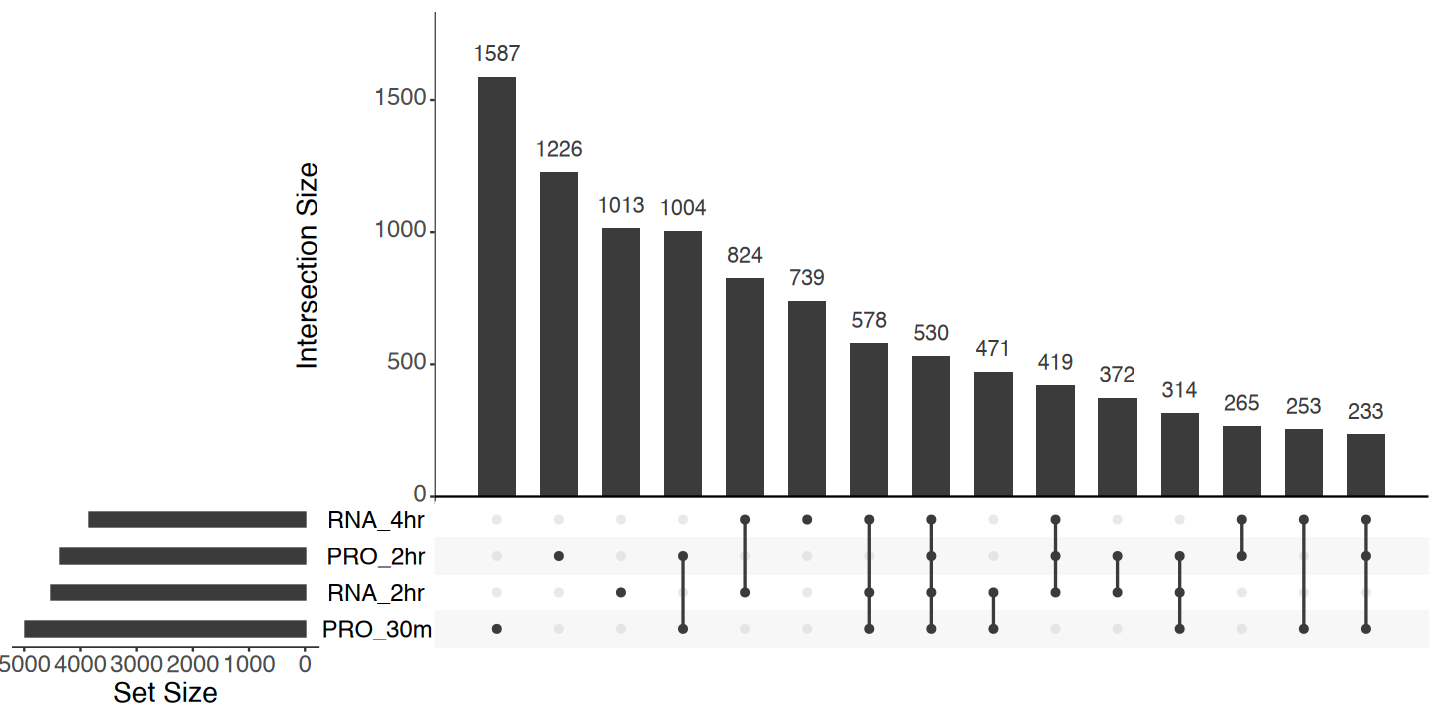

In [11]:
library(UpSetR)
options(repr.plot.width=12, repr.plot.height=6)
upset(fromList(list(RNA_2hr=rna_sig_2hr, RNA_4hr=rna_sig_4hr, PRO_30m=pro_sig_30m, PRO_2hr=pro_sig_2hr)), order.by="freq", nsets=4, text.scale=2)

Biggest shared number were the PRO-seq specific (N=1004) followed by RNA-speicifc (N=824) and shared across all (N=530). Then there are different combinations with PRO-seq 30min having more similarities.

The number of genes unique to a timepoint/assay were primarily dictated by PRO-seq and then number of genes called.

In [12]:
gene_universe = unique(c(rna_2hr$Gene, rna_4hr$Gene, pro_2hr$Gene, pro_30m$Gene))
gene_sig_universe = unique(c(rna_sig_2hr, rna_sig_4hr, pro_sig_2hr, pro_sig_30m))
rna_only = setdiff(intersect(rna_sig_2hr, rna_sig_4hr), union(pro_sig_30m, pro_sig_2hr))
pro_only = setdiff(intersect(pro_sig_30m, pro_sig_2hr), union(rna_sig_2hr, rna_sig_4hr))
all = intersect(intersect(rna_sig_2hr, rna_sig_4hr), intersect(pro_sig_30m, pro_sig_2hr))
length(rna_only); length(pro_only); length(all); length(gene_universe); length(gene_sig_universe)


[1] 824

[1] 1004

[1] 530

[1] 28889

[1] 9828

In [13]:
pro30_only = setdiff(pro_sig_30m, union(pro_sig_2hr, union(rna_sig_2hr, rna_sig_4hr)))
pro2h_only = setdiff(pro_sig_2hr, union(pro_sig_30m, union(rna_sig_2hr, rna_sig_4hr)))
rna2h_only = setdiff(rna_sig_2hr, union(pro_sig_30m, union(pro_sig_2hr, rna_sig_4hr)))
rna4h_only = setdiff(rna_sig_4hr, union(pro_sig_30m, union(pro_sig_2hr, rna_sig_2hr)))
length(pro30_only); length(pro2h_only); length(rna2h_only); length(rna4h_only)

[1] 1587

[1] 1226

[1] 1013

[1] 739

### Run GO analyses on the genes in different significance categories

In [ ]:

run_go_analysis <- function(gene_symbols, gene_univ_use) {
    # gene_ids <- bitr(gene_symbols, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
    # # Extract the Entrez IDs
    # entrez_gene_list <- gene_ids$ENTREZID
    # GO enrichment analysis
    go_enrichment <- enrichGO(gene = gene_symbols,
                          OrgDb = org.Hs.eg.db, universe=gene_univ_use,
                          keyType = "SYMBOL",
                          ont = "ALL",  # Can be "BP", "MF", or "CC" for specific ontology categories
                          pAdjustMethod = "BH",
                          pvalueCutoff = 0.05,
                          qvalueCutoff = 0.05)

    return(go_enrichment)
    }

#### Using the SIGNIFICANT genes as the universe

In [16]:
GO_rna_only <- run_go_analysis(rna_only, gene_sig_universe)
GO_pro_only <- run_go_analysis(pro_only, gene_sig_universe)
GO_all <- run_go_analysis(all, gene_sig_universe)

In [17]:
GO_rna2h_only <- run_go_analysis(rna2h_only, gene_sig_universe)
GO_rna4h_only <- run_go_analysis(rna4h_only, gene_sig_universe)
GO_pro30_only <- run_go_analysis(pro30_only, gene_sig_universe)
GO_pro2h_only <- run_go_analysis(pro2h_only, gene_sig_universe)

In [24]:
GO_pro_only_genelist <- unique(unlist(sapply(GO_pro_only$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nPRO: Num Orig:", length(GO_pro_only@gene), "    Num With Calls:", length(GO_pro_only_genelist))
GO_all_genelist <- unique(unlist(sapply(GO_all$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nALL: Num Orig:", length(GO_all@gene), "    Num With Calls:", length(GO_all_genelist))
GO_rna_only_genelist <- unique(unlist(sapply(GO_rna_only$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nRNA: Num Orig:", length(GO_rna_only@gene), "    Num With Calls:", length(GO_rna_only_genelist))
GO_pro_only_genelist[1:4]
rna_only[1:4]


GO_pro30_only_genelist <- unique(unlist(sapply(GO_pro30_only$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nPRO30: Num Orig:", length(GO_pro30_only@gene), "    Num With GO Calls:", length(GO_pro30_only_genelist))
GO_pro2h_only_genelist <- unique(unlist(sapply(GO_pro2h_only$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nPRO2H: Num Orig:", length(GO_pro2h_only@gene), "    Num With GO Calls:", length(GO_pro2h_only_genelist))
GO_rna2h_only_genelist <- unique(unlist(sapply(GO_rna2h_only$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nRNA2H: Num Orig:", length(GO_rna2h_only@gene), "    Num With Calls:", length(GO_rna2h_only_genelist))
GO_rna4h_only_genelist <- unique(unlist(sapply(GO_rna4h_only$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nRNA4H: Num Orig:", length(GO_rna4h_only@gene), "    Num With GO Calls:", length(GO_rna4h_only_genelist))


PRO: Num Orig: 1004     Num With Calls: 144


ALL: Num Orig: 530     Num With Calls: 428
RNA: Num Orig: 824     Num With Calls: 0

[1] "MMP2"     "LGALS3BP" "COL18A1"  "SMOC1"

[1] "THBD"        "IRF1"        "NR4A1AS"     "ALDH1A3-AS1"


PRO30: Num Orig: 1587     Num With GO Calls: 256
PRO2H: Num Orig: 1226     Num With GO Calls: 383
RNA2H: Num Orig: 1013     Num With Calls: 0
RNA4H: Num Orig: 739     Num With GO Calls: 94

In [59]:
GO_pro_df <- as.data.frame(GO_pro_only)
#GO_all_df[1:2,]
GO_pro_df$Category <- "None"

GO_pro_df[grepl("lysosom|lytic vacuole|vacuole|vacuolar lumen", GO_pro_df$Description),]$Category <- "Lysosome"
GO_pro_df[grepl("extracellular matrix", GO_pro_df$Description),]$Category <- "ECM"
GO_pro_df[grepl("external encapsulating", GO_pro_df$Description),]$Category <- "External encapsulating structure"
GO_pro_df[grepl("clathrin", GO_pro_df$Description),]$Category <- "Clathrin vesicle coat"
GO_pro_df[grepl("calcium", GO_pro_df$Description),]$Category <- "calcium ion binding"

filt = GO_pro_df[GO_pro_df$Category == "None",]
dim(filt)
filt[,c("ONTOLOGY", "Description", "zScore", "p.adjust", "qvalue", "geneID", "Count", "Category")]

GO_pro_df$Max_call <- 0
for (group in unique(GO_pro_df$Category)) {
	
    filt = GO_pro_df[GO_pro_df$Category == group,]
    max_call = max(filt$zScore)
	if (group == "None") {max_call = 0}
    GO_pro_df[GO_pro_df$Category == group,]$Max_call = max_call
    }

[1]  0 14

ONTOLOGY,Description,zScore,p.adjust,qvalue,geneID,Count,Category
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>


In [55]:
GO_all_df <- as.data.frame(GO_all)
#GO_all_df[1:2,]
GO_all_df$Category <- "None"
GO_all_df[grepl("MAPK|ERK|phosphorylation|tyrosine kinase signaling|phosphorus metabolic|phosphate metabolic|protein modification|kinase|peptidyl-tyrosine", GO_all_df$Description),]$Category <- "MAPK/ERK & TYK cascade"
GO_all_df[grepl("Wnt|wnt", GO_all_df$Description),]$Category <- "Wnt cascade"
GO_all_df[grepl("NF-kappaB", GO_all_df$Description),]$Category <- "NFKB signaling"
#GO_all_df[grepl("dexamethasone", GO_all_df$Description),]$Category <- "DEX Response"
GO_all_df[grepl("glucose|positive regulation of catabolic|biosynthetic|metabolic", GO_all_df$Description),]$Category <- "Metabolism"
GO_all_df[grepl("tissue regeneration|cell size|cell shape|cell growth|anatomical structure arrangement|embryo|cell gorwth|cellular component biogenesis|BMP|endoderm|mesoderm|cellular component size|tube closure|regulation of growth|tissue growth|neurogenesis|organ growth|tissue remodeling|gastrulation|epiboly|development|reproductive|axonogenesis|pregnancy|fate commitment|differentiation|germ layer|mesonephros|bone mineralization|tube formation|epithelial tube formation|structure size|gliogenesis|cell differentiation|embryotissue remodeling|morphogenesis|renal system|ossification", GO_all_df$Description),]$Category <- "Morphogenesis/Dvlpt/Differentiation"
GO_all_df[grepl("hemostasis|vascular|vasculogenesis|vasculature|blood vessel|angiogenesis|vascular process|blood circulat|circulatory|hemopoiesis", GO_all_df$Description),]$Category <- "Angiogenesis"
GO_all_df[grepl("platelet|coagulation|wound healing|response to wounding", GO_all_df$Description),]$Category <- "Wound Healing"
GO_all_df[grepl("oxygen|hypoxia|ischemia", GO_all_df$Description),]$Category <- "Oxygen Response"
GO_all_df[grepl("growth factor|SMAD", GO_all_df$Description),]$Category <- "Growth Factor Response"
GO_all_df[grepl("glucocorticoid|corticosteroid|steroid hormone|steroid|response to mineralocorticoid", GO_all_df$Description),]$Category <- "Glucocorticoid Response"
GO_all_df[grepl("EMT|epithelial to mesenchymal transition|mesenchyme development|cell-substrate adhesion|cell adhesion|cell-matrix adhesion|focal adhesion|cell-substrate junction|cell junction", GO_all_df$Description),]$Category <- "EMT"
GO_all_df[grepl("actin|actomyosin|extracellular matrix|extracellular structure|encapsulating structure|cytoskeleton|microtubule|supramolecular fiber", GO_all_df$Description),]$Category <- "Cytoskeleton/ECM"
GO_all_df[grepl("cell migration|locomotion|cell motility|taxis|epithelium migration|tissue migration", GO_all_df$Description),]$Category <- "Cell Migration"
GO_all_df[grepl("proliferation|cell division", GO_all_df$Description),]$Category <- "Proliferation"
GO_all_df[grepl("immune|interleukin|autophagy|tumor necrosis|alpha-beta T|lymphocyte|leukocyte|lipopolysaccharide|bacterium|bacterial origin|cytokine|leukocyte diff|programmed cell death|apopto|inflammatory|B cell|immune response", GO_all_df$Description),]$Category <- "Immune Response"
GO_all_df[grepl("miRNA metabolic|miRNA transcription|ncRNA transcription", GO_all_df$Description),]$Category <- "miRNA regulation"
GO_all_df[grepl("cell fusion|syncytium", GO_all_df$Description),]$Category <- "Cell fusion"
GO_all_df[grepl("DNA damage", GO_all_df$Description),]$Category <- "DNA damage response"
GO_all_df[grepl("membrane permeability", GO_all_df$Description),]$Category <- "Membrane permeability"

GO_all_df[grepl("response to organic cyclic|response to ketone|response to progesterone|response to hormone|response to toxic substance", GO_all_df$Description),]$Category <- "Org Compound Response"
GO_all_df[grepl("cellular response to biotic stimulus|positive regulation of catalytic activity|protein localization|transcription regulator|nuclear migration|positive regulation of response to external stimulus|regulation of small molecule metabolic process|regulation of protein binding|positive regulation of transferase activity|negative regulation of translation	|negative regulation of molecular function|import into cell|egulation of carbohydrate metabolic process|negative regulation of protein metabolic process|regulation of binding|nucleus localization|response to lipid|negative regulation of response to external stimulus|cellular response to external stimulus|synaptic|DNA binding|protein localization to nucleus|response to extracellular stimulus|regulation of DNA-binding transcription factor activity|intracellular signal transduction|multicellular organism process|multicellular organismal-level homeostasis", GO_all_df$Description),]$Category <- "General Response"
filt = GO_all_df[GO_all_df$Category == "None",]
dim(filt)
filt[1:25,c("ONTOLOGY", "Description", "zScore", "p.adjust", "qvalue", "geneID", "Count", "Category")]

GO_all_df$Max_call <- 0
for (group in unique(GO_all_df$Category)) {
	
    filt = GO_all_df[GO_all_df$Category == group,]
    max_call = max(filt$zScore)
	if (group == "None") {max_call = 0}
    GO_all_df[GO_all_df$Category == group,]$Max_call = max_call
    }

[1] 41 14

,ONTOLOGY,Description,zScore,p.adjust,qvalue,geneID,Count,Category
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0050878,BP,regulation of body fluid levels,4.013153,0.0070924696,0.0055547465,HK2/SRF/VEGFA/F3/PDGFB/DGKD/MYH9/PDGFA/PRICKLE1/VAV2/SERPINE1/MYL9/PLAUR/NPR3/CSRP1/ACTG1/ZBTB7B/DGKZ/CAD/FLNA/HIF1A/C1QTNF1/DDR1,23,None
GO:0030239,BP,myofibril assembly,4.161307,0.0159032512,0.0124552565,SRF/CFLAR/PLEC/LMOD1/MYL9/WDR1/CSRP1/ACTG1,8,None
GO:0017148,BP,negative regulation of translation,3.641624,0.0212052910,0.0166077574,AJUBA/SAMD4A/DAPK3/ZNF598/ENC1/AGO2/QKI/CPEB4/SYNCRIP/CPEB2/SESN2/SHMT2/EIF6,13,None
GO:0031638,BP,zymogen activation,3.945159,0.0239012519,0.0187192051,RUNX1/MMP14/SERPINE1/FURIN/PLAUR/FADD/VSIR,7,None
GO:0051338,BP,regulation of transferase activity,3.157072,0.0270269766,0.0211672393,VEGFA/EREG/ERRFI1/ABL1/MAP2K3/CARD10/CDKN1A/SPRY4/TRIB1/PDGFB/LRP5/DUSP1/CCN1/EPHA2/SMAD7/GREM1/FGF2/TNFRSF10A/CSF1/CCNF/SPRED1/NRG1/PDGFA/TRIB3/ZFP91/ROR2/SASH1/NHERF1/AXIN1/ROR1/DUSP7/EPHB4/MAP3K10/KSR1/SMG6/DDR1/NR2F2,37,None
GO:0007520,BP,myoblast fusion,3.973257,0.0271717360,0.0212806134,CFLAR/ADAMTS15/NFATC2/MYH9/PLEKHO1/FLOT1,6,None
GO:0006897,BP,endocytosis,3.141630,0.0271717360,0.0212806134,SNX18/VEGFA/SYNJ2/NEDD4L/SH3BP4/ABL1/CCL2/JMJD6/FCMR/DGKD/LRP5/GREM1/MYH9/CSNK1E/LPAR1/CSNK1D/VAV2/DLL1/RIN1/SERPINE1/PLPP4/TNK2/CNN2/BCL2L1/CACNG4/HIP1R/RHOBTB2/MTMR2/ACTG1/ATP9A/ICAM5/LDLRAP1/SCARA3/STX1B/RUFY1/FLOT1/BIN1/PDLIM7,38,None
GO:0090398,BP,cellular senescence,3.495357,0.0290338253,0.0227389818,SRF/MNT/ABL1/MAP2K3/CDKN1A/ZMIZ1/PLK2/LMNA/HMGA1/TP53/H2AX,11,None
GO:0007595,BP,lactation,3.843035,0.0313078619,0.0245199830,HK2/VEGFA/ZBTB7B/CAD/HIF1A/DDR1,6,None


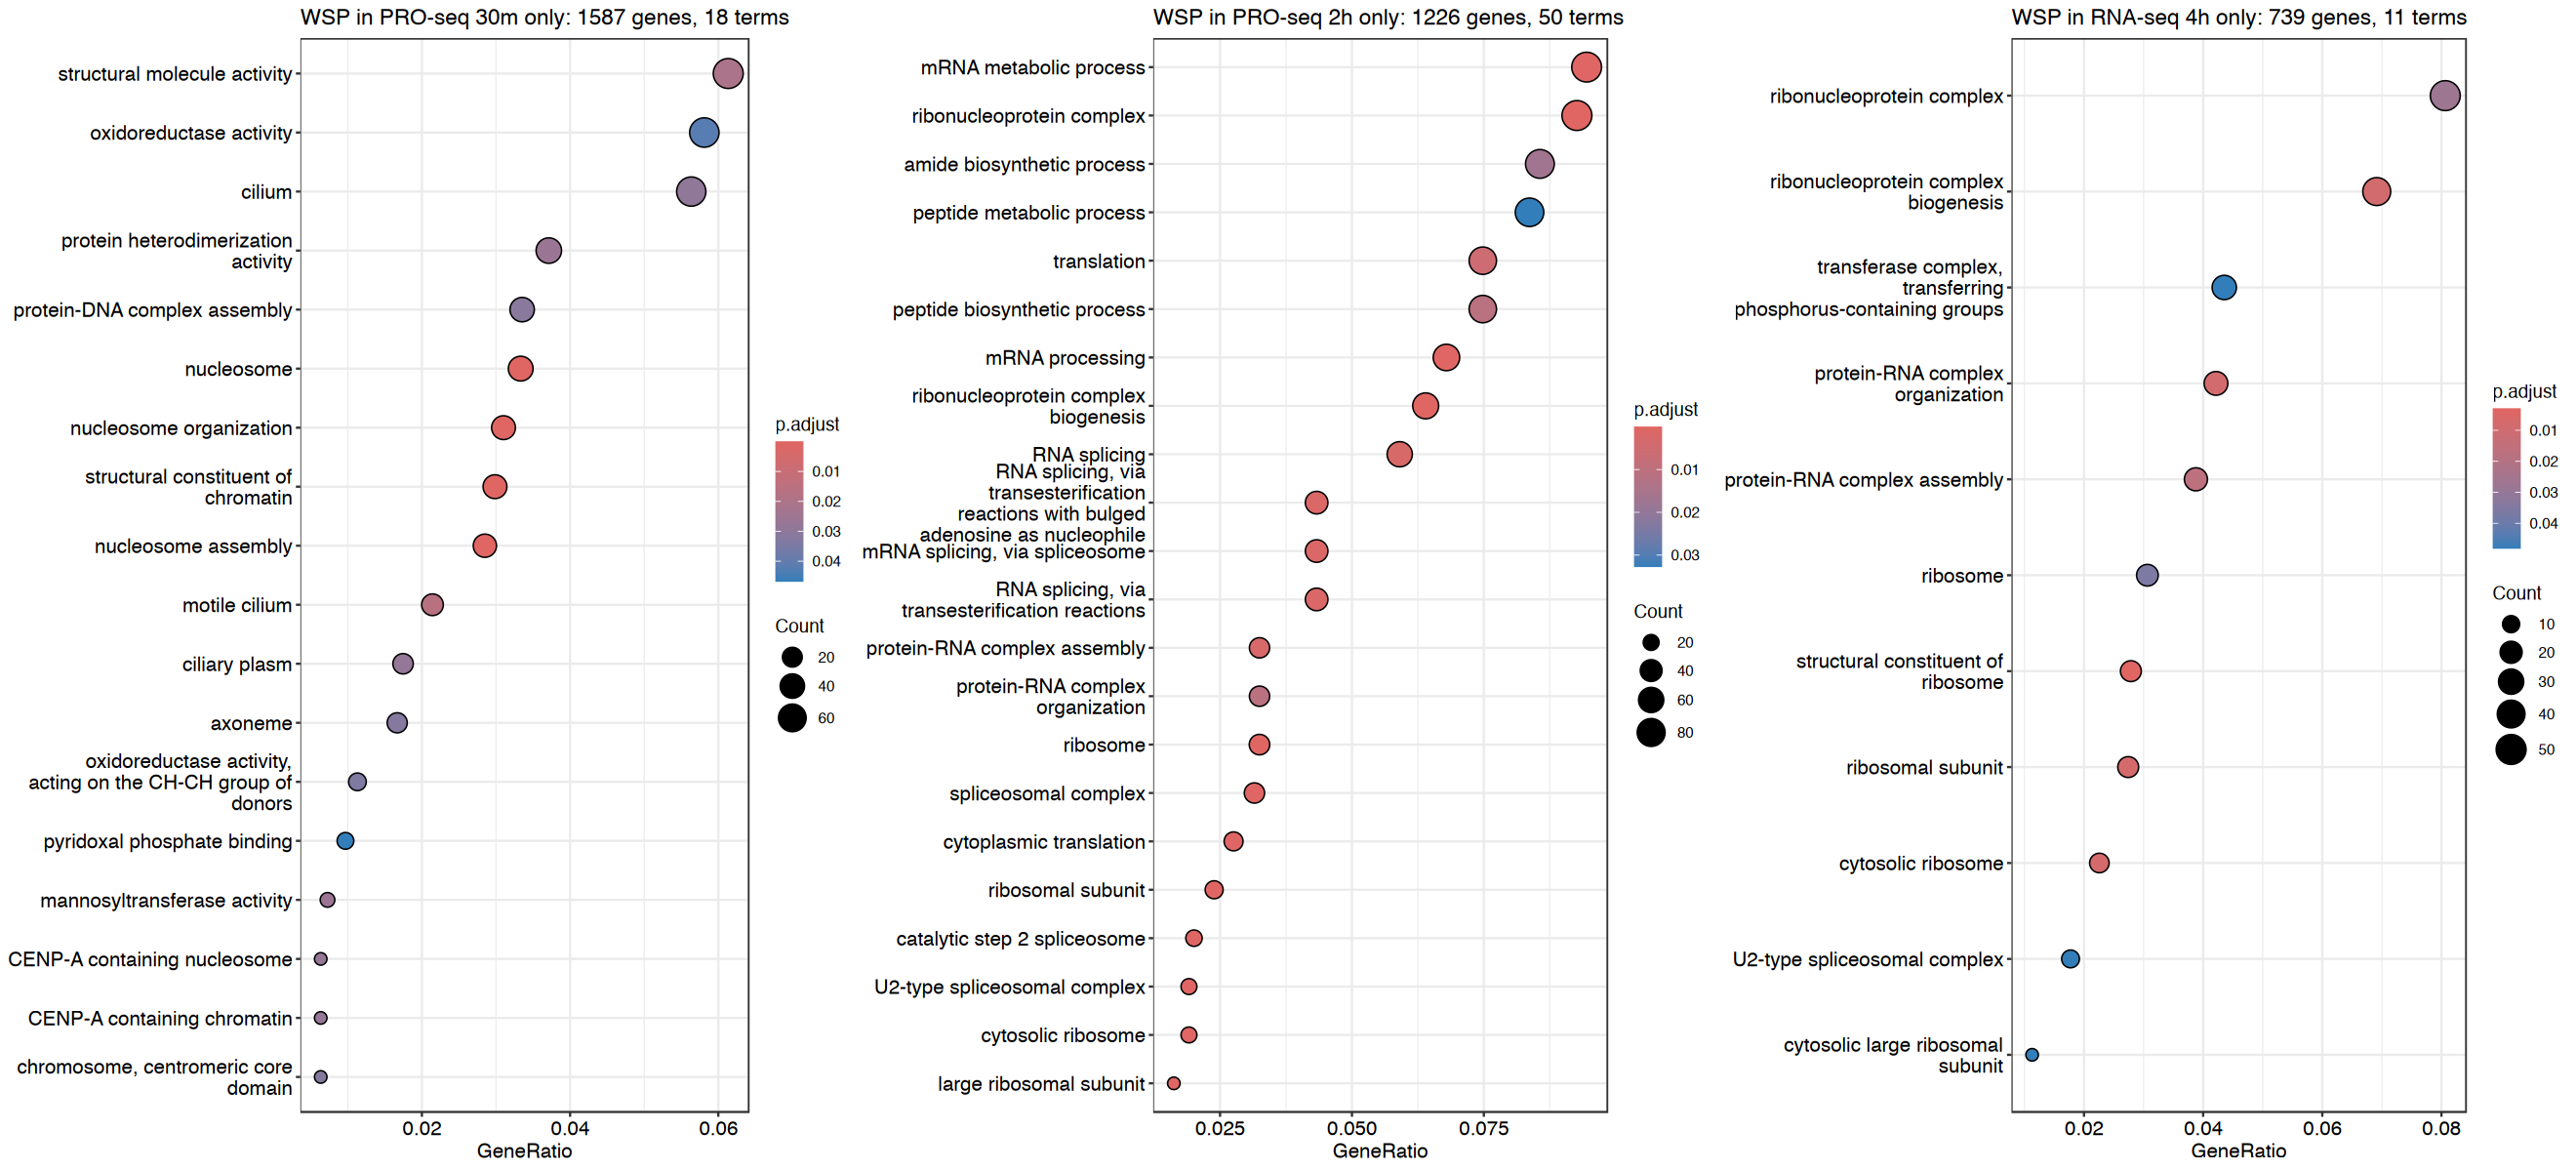

In [68]:
options(repr.plot.width=22)
p1 <- dotplot(GO_pro30_only, showCategory = 18, title="WSP in PRO-seq 30m only: 1587 genes, 18 terms")
p2 <- dotplot(GO_pro2h_only, showCategory = 22, title="WSP in PRO-seq 2h only: 1226 genes, 50 terms")
#p3 <- dotplot(GO_rna2h_only, showCategory = 18, title="WSP in RNA-seq 2h only: 1013 genes, 0 terms")
p4 <- dotplot(GO_rna4h_only, showCategory = 18, title="WSP in RNA-seq 4h only: 739 genes, 11 terms")
grid.arrange(p1, p2, p4,  ncol = 3)

In [74]:
GO_pro30_df <- as.data.frame(GO_pro30_only)
#GO_all_df[1:2,]
GO_pro30_df$Category <- "None"

GO_pro30_df[grepl("cilium|ciliary|axoneme", GO_pro30_df$Description),]$Category <- "Cilia"
GO_pro30_df[grepl("nucleosome|protein-DNA complex|structural constituent of chromatin", GO_pro30_df$Description),]$Category <- "Nucleosome"
GO_pro30_df[grepl("centromer|CENP-A", GO_pro30_df$Description),]$Category <- "Centromere"
GO_pro30_df[grepl("oxidoreductase", GO_pro30_df$Description),]$Category <- "Oxidoreductase activity"
GO_pro30_df[grepl("mannosyltransferase", GO_pro30_df$Description),]$Category <- "Mannosyltransferase activity"
GO_pro30_df[grepl("protein hetero", GO_pro30_df$Description),]$Category <- "Protein heterodimerization"
GO_pro30_df[grepl("pyridoxal phosphate", GO_pro30_df$Description),]$Category <- "Pyridoxal phosphate binding"
GO_pro30_df[grepl("structural molecule", GO_pro30_df$Description),]$Category <- "Structural molecule activity"

filt = GO_pro30_df[GO_pro30_df$Category == "None",]
dim(filt)
filt[,c("ONTOLOGY", "Description", "zScore", "p.adjust", "qvalue", "geneID", "Count", "Category")]

GO_pro30_df$Max_call <- 0
for (group in unique(GO_pro30_df$Category)) {
	
    filt = GO_pro30_df[GO_pro30_df$Category == group,]
    max_call = max(filt$zScore)
	if (group == "None") {max_call = 0}
    GO_pro30_df[GO_pro30_df$Category == group,]$Max_call = max_call
    }

[1]  0 14

ONTOLOGY,Description,zScore,p.adjust,qvalue,geneID,Count,Category
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>


In [84]:
GO_pro2h_df <- as.data.frame(GO_pro2h_only)
#GO_all_df[1:2,]
GO_pro2h_df$Category <- "None"

GO_pro2h_df[grepl("peptide metabolic|translation|ribosom|peptide biosynthetic|amide biosynthetic", GO_pro2h_df$Description),]$Category <- "Translation"
GO_pro2h_df[grepl("nuclease|catalytic activity, acting on|3'-5' exonuclease|mRNA binding|Sm-like protein family complex|snRNP|spliceosom|mRNA processing|mRNA metabolic|splicing|ribonucleoprotein|protein-RNA", GO_pro2h_df$Description),]$Category <- "mRNA processing/degradation"
GO_pro2h_df[grepl("ubiquitin|peptidase|proteasome", GO_pro2h_df$Description),]$Category <- "Protein degradation"
GO_pro2h_df[grepl("nuclear chromosome", GO_pro2h_df$Description),]$Category <- "chromosome"
GO_pro2h_df[grepl("inner membrane|mitochondrial matrix", GO_pro2h_df$Description),]$Category <- "Organelle inner membrane"
GO_pro2h_df[grepl("ATP-dependent", GO_pro2h_df$Description),]$Category <- "ATP-dependent activity"
GO_pro2h_df[grepl("protein-containing complex", GO_pro2h_df$Description),]$Category <- "Protein-containing complex"
GO_pro2h_df[grepl("molecular carrier", GO_pro2h_df$Description),]$Category <- "Molecular carrier"
GO_pro2h_df[grepl("helicase activity", GO_pro2h_df$Description),]$Category <- "Helicase activity"

filt = GO_pro2h_df[GO_pro2h_df$Category == "None",]
dim(filt)
filt[,c("ONTOLOGY", "Description", "zScore", "p.adjust", "qvalue", "geneID", "Count", "Category")]

GO_pro2h_df$Max_call <- 0
for (group in unique(GO_pro2h_df$Category)) {
	
    filt = GO_pro2h_df[GO_pro2h_df$Category == group,]
    max_call = max(filt$zScore)
	if (group == "None") {max_call = 0}
    GO_pro2h_df[GO_pro2h_df$Category == group,]$Max_call = max_call
    }

[1]  0 14

ONTOLOGY,Description,zScore,p.adjust,qvalue,geneID,Count,Category
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>


In [93]:
GO_rna4h_df <- as.data.frame(GO_rna4h_only)
#GO_all_df[1:2,]
GO_rna4h_df$Category <- "None"

GO_rna4h_df[grepl("ribosom", GO_rna4h_df$Description),]$Category <- "Translation"
GO_rna4h_df[grepl("ribonucleoprotein|protein-RNA", GO_rna4h_df$Description),]$Category <- "Protein-RNA complex"
GO_rna4h_df[grepl("spliceosomal", GO_rna4h_df$Description),]$Category <- "Spliceosome"
GO_rna4h_df[grepl("phosphorus-containing", GO_rna4h_df$Description),]$Category <- "Transferring of\nphosphorus-containing\ngroups"

filt = GO_rna4h_df[GO_rna4h_df$Category == "None",]
dim(filt)
filt[,c("ONTOLOGY", "Description", "zScore", "p.adjust", "qvalue", "geneID", "Count", "Category")]

GO_rna4h_df$Max_call <- 0
for (group in unique(GO_rna4h_df$Category)) {
	
    filt = GO_rna4h_df[GO_rna4h_df$Category == group,]
    max_call = max(filt$zScore)
	if (group == "None") {max_call = 0}
    GO_rna4h_df[GO_rna4h_df$Category == group,]$Max_call = max_call
    }

[1]  0 14

ONTOLOGY,Description,zScore,p.adjust,qvalue,geneID,Count,Category
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>


Warning message:
"The following aesthetics were dropped during statistical transformation: size.
i This can happen when ggplot fails to infer the correct grouping structure in
  the data.
i Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"
Warning message:
"The following aesthetics were dropped during statistical transformation: size.
i This can happen when ggplot fails to infer the correct grouping structure in
  the data.
i Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"
Warning message:
"Cannot compute density for groups with fewer than two datapoints."
Warning message:
"The following aesthetics were dropped during statistical transformation: size.
i This can happen when ggplot fails to infer the correct grouping structure in
  the data.
i Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"
Warning message:
"Cannot compute density for gro

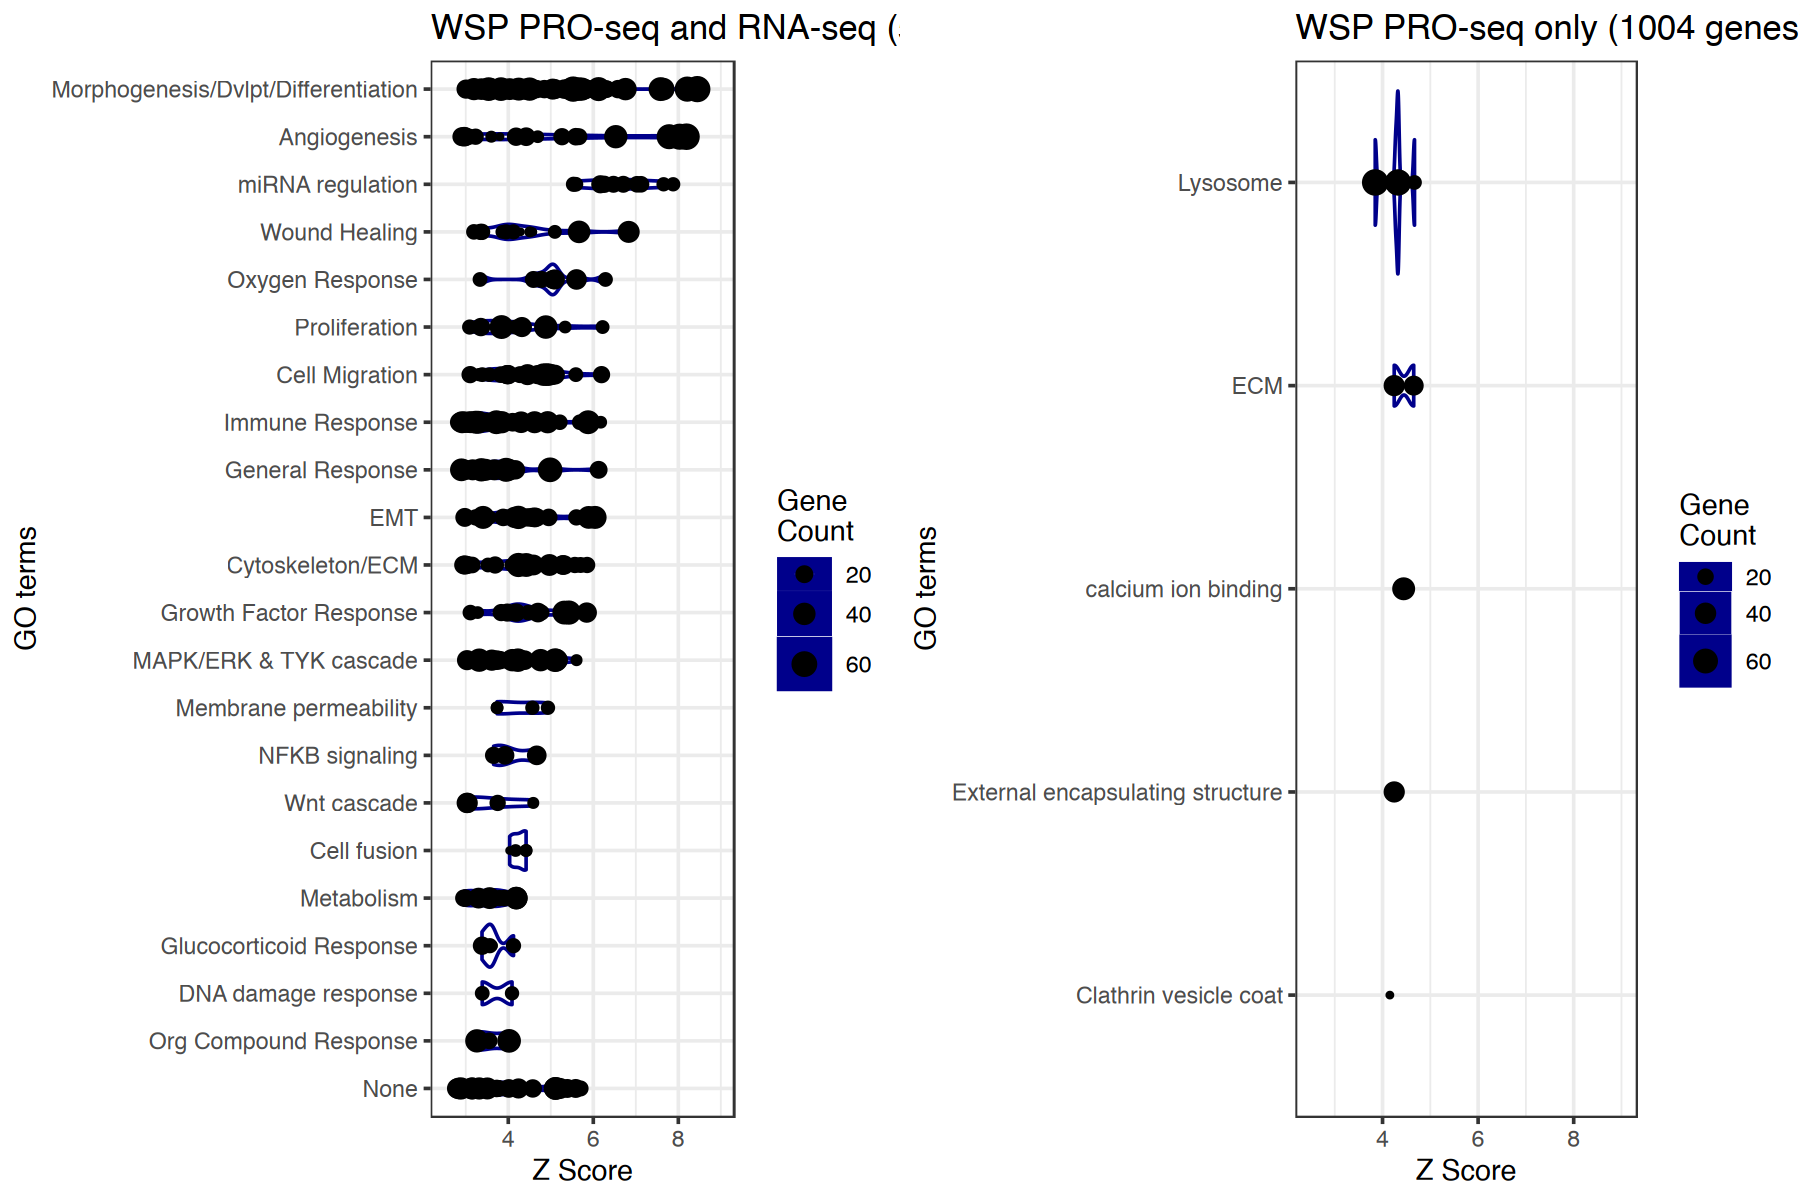

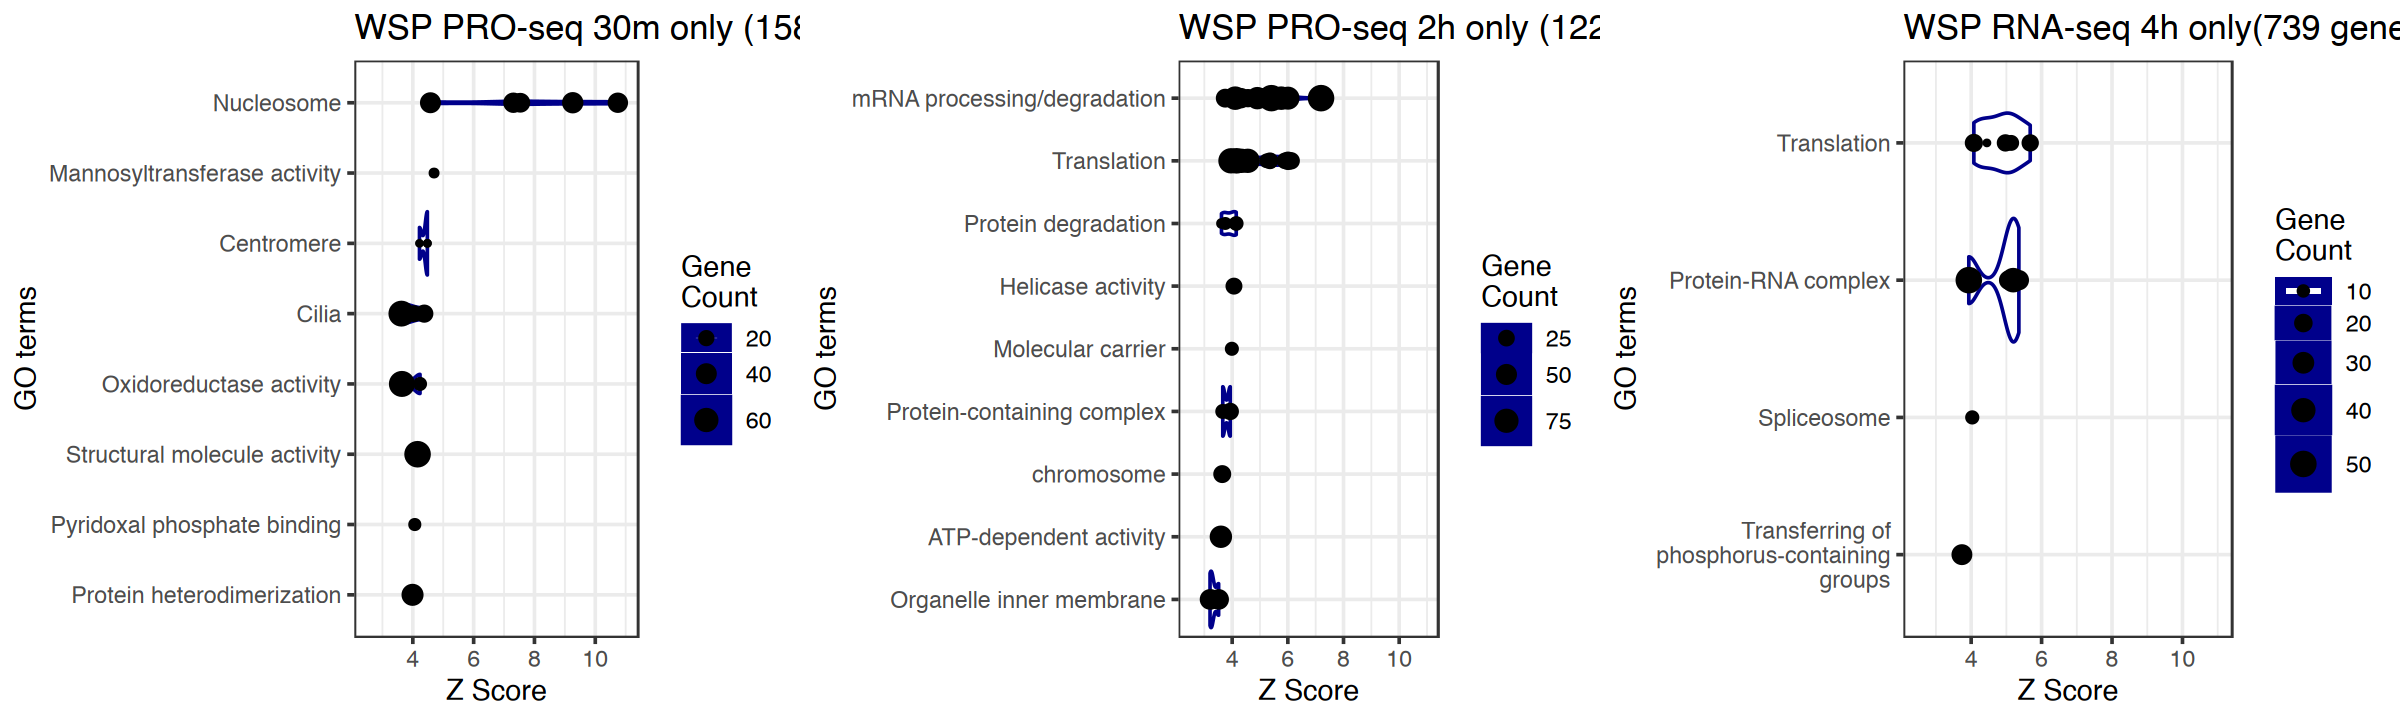

In [99]:

library(ggplot2)
base_size_use = 17
low_bar=2.5
pBOTH <- ggplot(GO_all_df, aes(x=zScore, y=reorder(Category, Max_call), size=Count)) + 
geom_violin(color = "darkblue", drop=FALSE) + geom_point() + theme_bw(base_size=base_size_use) + xlim(low_bar, 9) +
labs(y="GO terms", x="Z Score") + ggtitle("WSP PRO-seq and RNA-seq (530 genes)") + labs(size="Gene\nCount")

pPRO <- ggplot(GO_pro_df, aes(x=zScore, y=reorder(Category, Max_call), size=Count)) + 
geom_violin(color = "darkblue", drop=FALSE) + geom_point() + theme_bw(base_size=base_size_use) + xlim(low_bar, 9) +
labs(y="GO terms", x="Z Score") + ggtitle("WSP PRO-seq only (1004 genes)") + labs(size="Gene\nCount")

pPRO30 <- ggplot(GO_pro30_df, aes(x=zScore, y=reorder(Category, Max_call), size=Count)) + 
geom_violin(color = "darkblue", drop=FALSE) + geom_point() + theme_bw(base_size=base_size_use) + xlim(low_bar, 11) +
labs(y="GO terms", x="Z Score") + ggtitle("WSP PRO-seq 30m only (1587 genes)") + labs(size="Gene\nCount")

pPRO2 <- ggplot(GO_pro2h_df, aes(x=zScore, y=reorder(Category, Max_call), size=Count)) + 
geom_violin(color = "darkblue", drop=FALSE) + geom_point() + theme_bw(base_size=base_size_use) + xlim(low_bar, 11) +
labs(y="GO terms", x="Z Score") + ggtitle("WSP PRO-seq 2h only (1226 genes)") + labs(size="Gene\nCount")

pRNA4 <- ggplot(GO_rna4h_df, aes(x=zScore, y=reorder(Category, Max_call), size=Count)) + 
geom_violin(color = "darkblue", drop=FALSE) + geom_point() + theme_bw(base_size=base_size_use) + xlim(low_bar, 11) +
labs(y="GO terms", x="Z Score") + ggtitle("WSP RNA-seq 4h only(739 genes)") + labs(size="Gene\nCount")

library(cowplot)
options(repr.plot.width=15, repr.plot.height=10)
plot_grid(pBOTH, pPRO, ncol=2)
options(repr.plot.width=20, repr.plot.height=6)
plot_grid(pPRO30, pPRO2, pRNA4, ncol=3)


#### Using the full gene list as the universe
Does this allow the RNA-seq only genes to have enriched terms?

In [100]:
GO_rna_only_full <- run_go_analysis(rna_only, gene_universe)
GO_pro_only_full <- run_go_analysis(pro_only, gene_universe)
GO_all_full <- run_go_analysis(all, gene_universe)

In [102]:
GO_pro_only_genelist <- unique(unlist(sapply(GO_pro_only_full$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nPRO: Num Orig:", length(GO_pro_only_full@gene), "    Num With Calls:", length(GO_pro_only_genelist))
GO_all_genelist <- unique(unlist(sapply(GO_all_full$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nALL: Num Orig:", length(GO_all_full@gene), "    Num With Calls:", length(GO_all_genelist))
GO_rna_only_genelist <- unique(unlist(sapply(GO_rna_only_full$geneID, function(x) strsplit(x, "/")[[1]])))
cat("\nRNA: Num Orig:", length(GO_rna_only_full@gene), "    Num With Calls:", length(GO_rna_only_genelist))
GO_pro_only_genelist[1:4]


PRO: Num Orig: 1004     Num With Calls: 302
ALL: Num Orig: 530     Num With Calls: 418
RNA: Num Orig: 824     Num With Calls: 8

[1] "TKT"   "PDIA5" "G6PD"  "GPI"

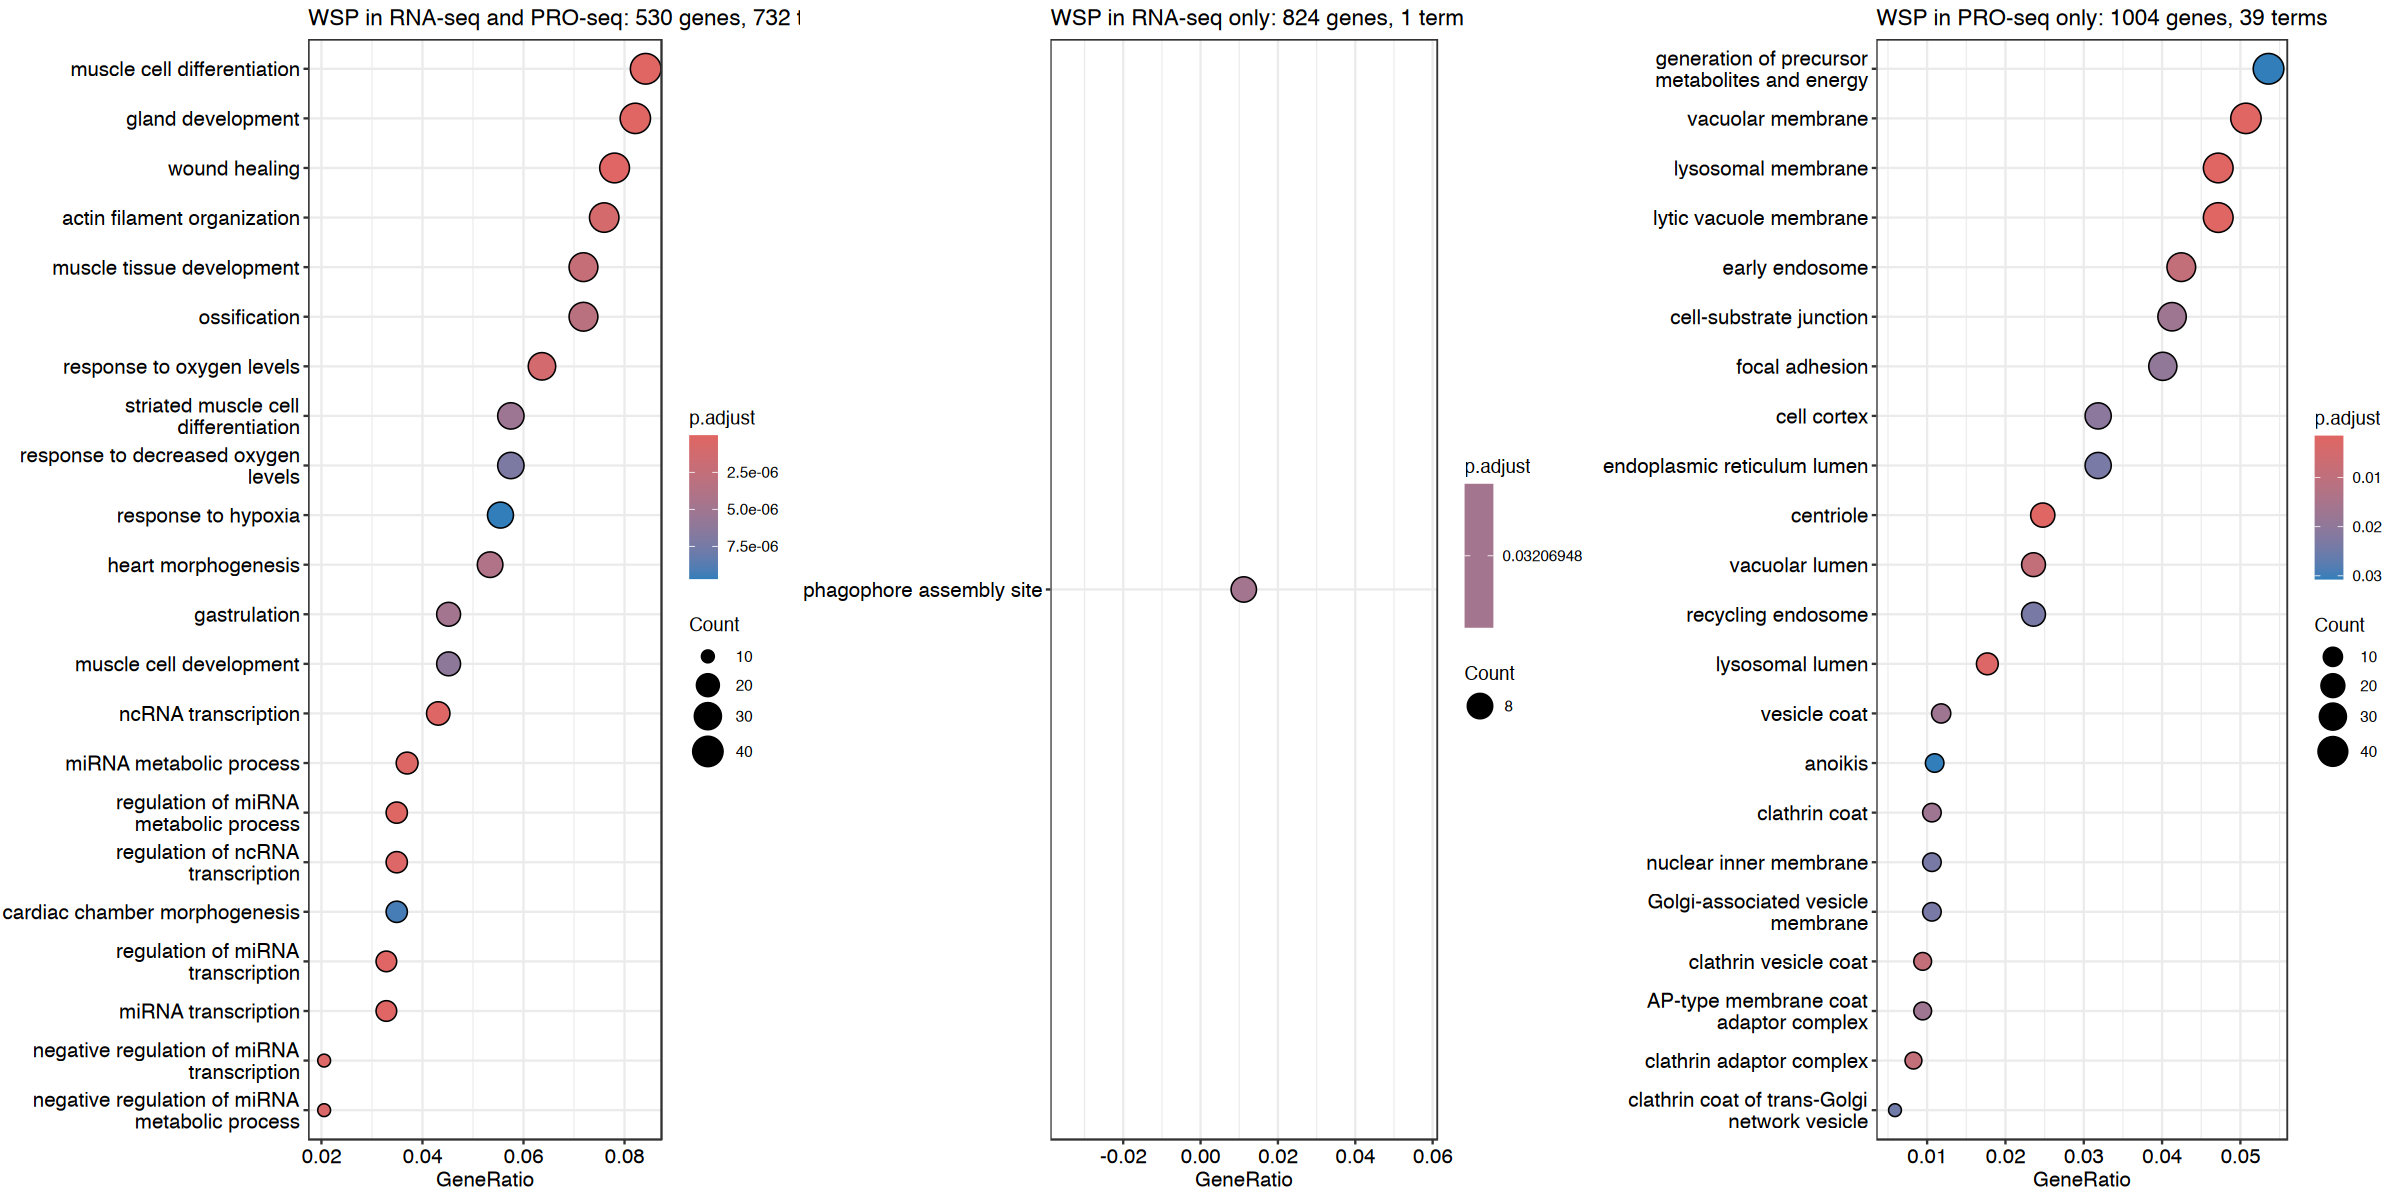

In [107]:
options(repr.plot.height=10, repr.plot.width=20)
p1 <- dotplot(GO_all_full, showCategory = 22, title="WSP in RNA-seq and PRO-seq: 530 genes, 732 terms")
p2 <- dotplot(GO_rna_only_full, showCategory = 18, title="WSP in RNA-seq only: 824 genes, 1 term")
p3 <- dotplot(GO_pro_only_full, showCategory = 22, title="WSP in PRO-seq only: 1004 genes, 39 terms")
grid.arrange(p1, p2, p3,   ncol = 3)

## How is directionality maintained?
It seems that the genes not sharing a response are not biased based on the PRO-seq timepoint in terms of binary response. However is the directionality maintained?

I would like to make a heatmap

In [112]:
total[1:2,]
dim(total)
total_df = as.data.frame(total)

# only keep the genes that are significant in both RNA-seq and PRO-seq
total_all = total_df[total_df$Gene %in% all,]
dim(total_all)
dim(total_all[complete.cases(total_all),])

,Gene,PRO_2hr_L2FC,PRO_2hr_padj,PRO_30m_L2FC,PRO_30m_padj,RNA_2hr_L2FC,RNA_2hr_padj,RNA_4hr_L2FC,RNA_4hr_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,-0.8461984,3.298741e-24,-1.356573,6.961514e-57,-0.11920881,0.4460511,-0.13139138,0.3919746
2,A1BG-AS1,-0.9451276,9.155087e-33,-1.442223,7.848995e-71,-0.05557541,0.6884666,-0.03907245,0.7908021


[1] 28889     9

[1] 530   9

[1] 530   9

In [ ]:
# group genes
# ONE different
# Group 1: up in all except down PROseq 2h
# SAME DIRECTIONS
# Group 1: up in all vs Group 2: down in all
# Assay difference
# Group 1: up in PRO-seq only vs Group 2: up in RNA-seq only
# 

In [227]:
upro[upro$Gene == "HAS1",]

Gene,UPM_2hr_L2FC,UPM_2hr_padj,UPM_30m_L2FC,UPM_30m_padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>


In [ ]:
upro[1:2,]



,Gene,UPM_2hr_L2FC,UPM_2hr_padj,UPM_30m_L2FC,UPM_30m_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,-0.4703207,0.2575699,-0.4182955,0.24873040
2,A1BG-AS1,0.1206626,0.9191742,-1.3773328,0.05729568


[1] 8 7

,Gene,PRO_30m_L2FC,PRO_2hr_L2FC,RNA_2hr_L2FC,RNA_4hr_L2FC,UPM_30m_L2FC,UPM_2hr_L2FC
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACTN1,ACTN1,1.2141094,-0.7391535,0.09317858,0.11329722,0.5014355,-0.175953670
CEMIP,CEMIP,-0.5748201,-1.6715216,0.08339111,0.62737540,-1.9300315,-0.336704540
CEMIP2,CEMIP2,0.4774170,0.2776495,0.40103897,0.31896085,1.0656022,-0.171630501
HAS2,HAS2,NA,NA,1.14977953,2.19728073,-1.6901083,-0.247665439
HAS3,HAS3,0.9726135,-1.4049375,0.91308164,0.50792026,-1.0080765,-0.159206099
HYAL1,HYAL1,-1.1968812,-0.3217479,-0.61275628,-0.93059072,-1.2862740,0.002775302
HYAL2,HYAL2,-0.8349489,-0.4321657,-0.18362177,-0.12090061,-0.9274069,-0.612638809
HYAL3,HYAL3,-1.5913661,-0.7236936,0.02027141,-0.05581503,-0.9216579,0.242265669


[1] 8 7

,Gene,PRO_30m_L2FC,PRO_2hr_L2FC,RNA_2hr_L2FC,RNA_4hr_L2FC,UPM_30m_L2FC,UPM_2hr_L2FC
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACTN1,ACTN1,1.2141094,-0.7391535,0.09317858,0.11329722,0.5014355,-0.175953670
CEMIP,CEMIP,-0.5748201,-1.6715216,0.08339111,0.62737540,-1.9300315,-0.336704540
CEMIP2,CEMIP2,0.4774170,0.2776495,0.40103897,0.31896085,1.0656022,-0.171630501
HAS2,HAS2,NA,NA,1.14977953,2.19728073,-1.6901083,-0.247665439
HAS3,HAS3,0.9726135,-1.4049375,0.91308164,0.50792026,-1.0080765,-0.159206099
HYAL1,HYAL1,-1.1968812,-0.3217479,-0.61275628,-0.93059072,-1.2862740,0.002775302
HYAL2,HYAL2,-0.8349489,-0.4321657,-0.18362177,-0.12090061,-0.9274069,-0.612638809
HYAL3,HYAL3,-1.5913661,-0.7236936,0.02027141,-0.05581503,-0.9216579,0.242265669


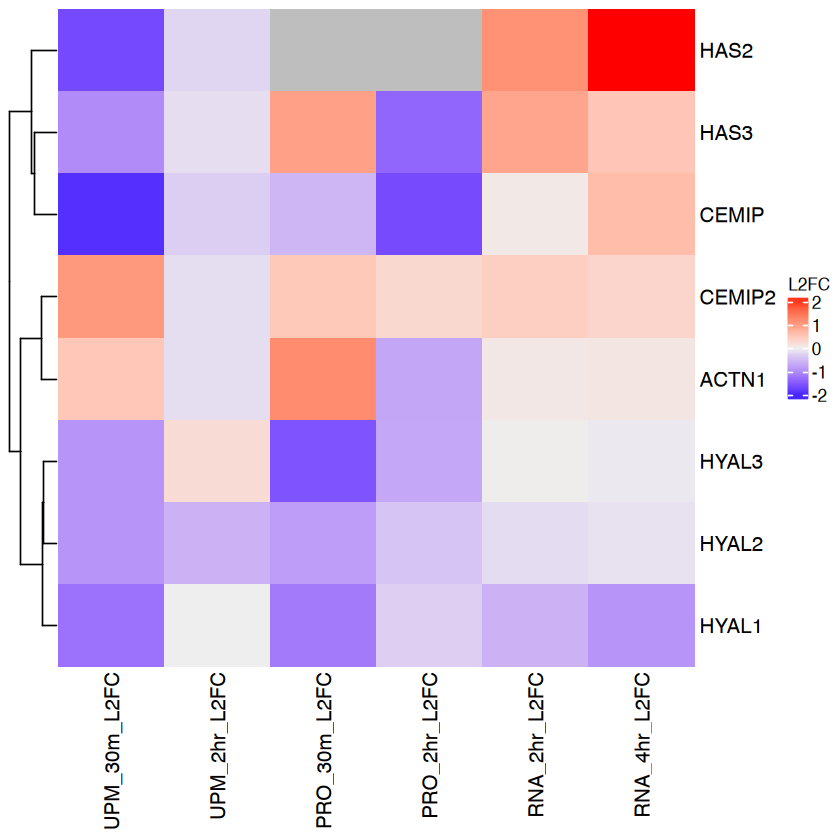

In [228]:
options(repr.plot.width=7, repr.plot.height=7)
total_hyal <- merge(total[,c("Gene", "PRO_30m_L2FC", "PRO_2hr_L2FC", "RNA_2hr_L2FC", "RNA_4hr_L2FC")], 
upro[,c("Gene", "UPM_30m_L2FC", "UPM_2hr_L2FC")], by="Gene")
total_hyal <- total_hyal[total_hyal$Gene %in% c(qrpcr_genes, "HAS1"),]
dim(total_hyal)
rownames(total_hyal) <- total_hyal$Gene
total_hyal
Heatmap(as.matrix(total_hyal[,c("UPM_30m_L2FC", "UPM_2hr_L2FC", "PRO_30m_L2FC", "PRO_2hr_L2FC", "RNA_2hr_L2FC", "RNA_4hr_L2FC")]), 
name="L2FC", show_row_names=TRUE, show_column_names=TRUE, cluster_rows=TRUE, cluster_columns=FALSE)

[1] 12  7

,Gene,PRO_30m_L2FC,PRO_2hr_L2FC,RNA_2hr_L2FC,RNA_4hr_L2FC,UPM_30m_L2FC,UPM_2hr_L2FC
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ALDOA,ALDOA,-0.40620167,-0.48178620,0.03681433,-0.009571196,-1.4634424,-0.24356750
CD44,CD44,-0.20804105,-0.25278127,-0.02942463,0.298173450,-0.5928666,-0.43945225
GFPT1,GFPT1,-0.47691989,0.17816041,0.08771075,0.053192321,-0.2516265,-0.07740881
IL6,IL6,0.03036447,-0.17904123,1.59296287,1.405478048,2.7502370,0.59522750
NFKB1,NFKB1,-0.66468877,-0.32052560,0.86457686,1.044047332,1.2609320,-0.46355805
PFKP,PFKP,0.80509963,-0.53442658,0.03934700,0.127871634,-1.2458515,-0.20221114
PGM1,PGM1,-0.42042240,0.50856396,0.05524816,-0.011132263,-1.7247236,-0.41456550
PGM3,PGM3,-0.36447154,-0.01833957,-0.09304117,0.052728461,-0.1457258,-0.28223197
PKM,PKM,-0.72109709,-0.38009193,-0.02946753,-0.007397597,-1.4089893,-0.30439268


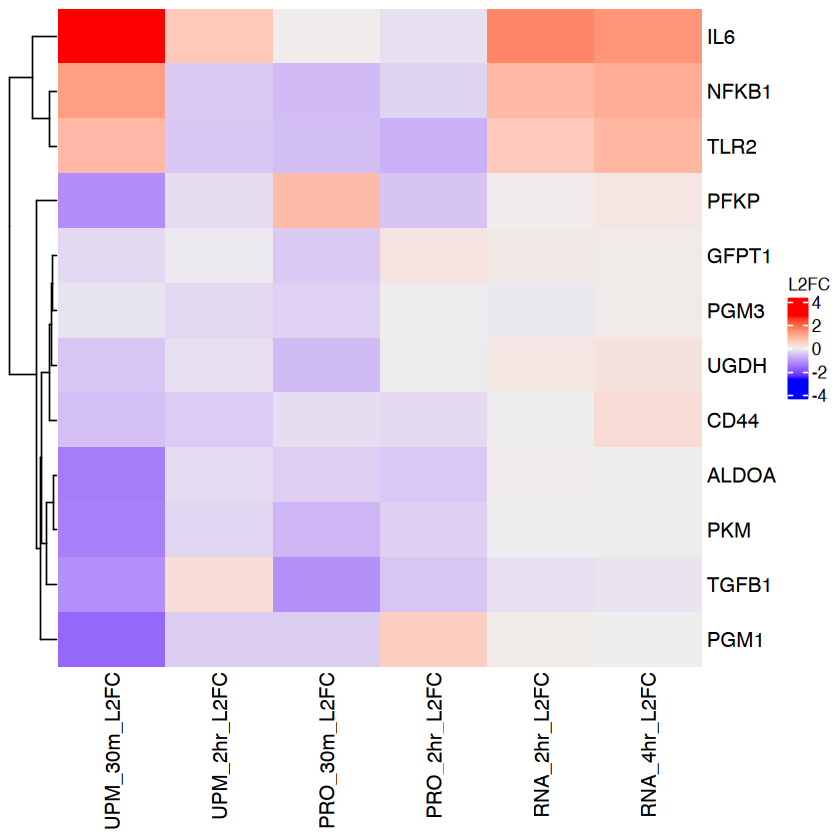

In [232]:
options(repr.plot.width=7, repr.plot.height=7)
total_hyal <- merge(total[,c("Gene", "PRO_30m_L2FC", "PRO_2hr_L2FC", "RNA_2hr_L2FC", "RNA_4hr_L2FC")], 
upro[,c("Gene", "UPM_30m_L2FC", "UPM_2hr_L2FC")], by="Gene")
total_hyal <- total_hyal[total_hyal$Gene %in% c("IL6", "TLR2", "NFKB1", "TGFB1", "TNFa", "CD44", "PGM3", "GFPT1", "UGDH", "UGBP2", "PGM1", "PKM", "ALDOA", "PFKP"),]
dim(total_hyal)
rownames(total_hyal) <- total_hyal$Gene
total_hyal
Heatmap(as.matrix(total_hyal[,c("UPM_30m_L2FC", "UPM_2hr_L2FC", "PRO_30m_L2FC", "PRO_2hr_L2FC", "RNA_2hr_L2FC", "RNA_4hr_L2FC")]), 
name="L2FC", show_row_names=TRUE, show_column_names=TRUE, cluster_rows=TRUE, cluster_columns=FALSE)

In [234]:
colnames(total)

[1] "Gene"         "PRO_2hr_L2FC" "PRO_2hr_padj" "PRO_30m_L2FC" "PRO_30m_padj"
[6] "RNA_2hr_L2FC" "RNA_2hr_padj" "RNA_4hr_L2FC" "RNA_4hr_padj"

In [252]:
hyal_genes = c("PFKP", "HAS3", "CEMIP", "UGP2", "LDHA", "HAS2", "PGM1", 
"GFPT1", "PGM3", "UGDH", "SLC17A5", "CD44", "FBP1", "PC", "HYAL1", "HYAL3", 
"TGFB1", "PKM", "ALDOA", "HYAL2", "GFPT2", "REL", "GNPNAT1", "TNF", "CEMIP2", 
"PGM2", "TLR2", "UAP1", "HAS1", "IL6")

# Build gene annotation
annotation_colors <- list(
  Pathway = c(
    "Precursor" = "#1b9e77",
    "Synthesis" = "#d95f02",
    "Degradation" = "#7570b3",
    "Signaling" = "#e7298a",
    "Transport" = "#66a61e"
  )
)
annotation_genes = c("Precursor", "Synthesis", "Degradation", "Precursor", "Precursor", "Synthesis", "Precursor", 
"Precursor", "Precursor", "Precursor", "Transport", "Transport", "Precursor", "Precursor", "Degradation", "Degradation", 
"Signaling", "Precursor", "Precursor", "Degradation", "Precursor", "Signaling", "Precursor", "Signaling", "Signaling",
"Precursor", "Signaling", "Precursor", "Synthesis", "Signaling")
gene_annotation_df <- data.frame(
  Pathway = annotation_genes,
  row.names = hyal_genes
)


total_hyal <- merge(total, upro, by="Gene")
total_hyal <- total_hyal[total_hyal$Gene %in% hyal_genes,]
dim(total_hyal)
colnames(total_hyal)
colnames(total_hyal) <- c("Gene", "PRO_WSP_2hr", "PRO_WSP_2hr_padj", "PRO_WSP_30m", "PRO_WSP_30m_padj",
"RNA_WSP_2hr", "RNA_WSP_2hr_padj", "RNA_WSP_4hr", "RNA_WSP_4hr_padj",
"PRO_UPM_2hr", "PRO_UPM_2hr_padj", "PRO_UPM_30m", "PRO_UPM_30m_padj")
total_hyal

[1] 29 13

[1] "Gene"         "PRO_2hr_L2FC" "PRO_2hr_padj" "PRO_30m_L2FC" "PRO_30m_padj"
 [6] "RNA_2hr_L2FC" "RNA_2hr_padj" "RNA_4hr_L2FC" "RNA_4hr_padj" "UPM_2hr_L2FC"
[11] "UPM_2hr_padj" "UPM_30m_L2FC" "UPM_30m_padj"

,Gene,PRO_WSP_2hr,PRO_WSP_2hr_padj,PRO_WSP_30m,PRO_WSP_30m_padj,RNA_WSP_2hr,RNA_WSP_2hr_padj,RNA_WSP_4hr,RNA_WSP_4hr_padj,PRO_UPM_2hr,PRO_UPM_2hr_padj,PRO_UPM_30m,PRO_UPM_30m_padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
543,ALDOA,-0.48178620,5.500624e-15,-0.40620167,5.091066e-11,0.03681433,6.083767e-02,-0.009571196,7.274998e-01,-0.243567502,1.653458e-02,-1.46344240,7.411046e-65
2510,CD44,-0.25278127,1.824080e-08,-0.20804105,4.130651e-06,-0.02942463,5.400157e-01,0.298173450,1.196118e-22,-0.439452251,1.039778e-10,-0.59286656,4.320233e-20
2698,CEMIP,-1.67152157,1.251830e-69,-0.57482009,3.543425e-10,0.08339111,6.433602e-01,0.627375403,9.269985e-09,-0.336704540,1.409137e-07,-1.93003153,7.139937e-234
2699,CEMIP2,0.27764947,4.089804e-07,0.47741699,6.457068e-19,0.40103897,2.411469e-47,0.318960848,1.389823e-29,-0.171630501,6.985341e-02,1.06560220,4.958730e-46
5307,FBP1,NA,NA,NA,NA,0.55213449,NA,1.237590366,NA,-0.637278784,2.431643e-03,-0.97968585,2.866127e-07
5962,GFPT1,0.17816041,2.663627e-03,-0.47691989,2.132872e-16,0.08771075,1.636478e-02,0.053192321,2.105395e-01,-0.077408808,4.672879e-01,-0.25162645,1.069941e-03
5963,GFPT2,-0.25461774,2.988859e-06,-1.62224021,2.481478e-195,-0.22769169,3.967739e-07,0.174205143,1.955559e-04,-0.215920733,7.391935e-01,-0.30342246,5.445538e-01
6133,GNPNAT1,0.34566247,9.492335e-04,0.29983235,4.579319e-03,-0.03987302,2.343257e-01,0.020591507,6.089615e-01,0.027682547,9.351958e-01,0.14516788,5.140486e-01
6595,HAS2,NA,NA,NA,NA,1.14977953,NA,2.197280728,NA,-0.247665439,3.301788e-01,-1.69010827,2.309436e-19


In [255]:

# Get expression matrix
mat <- as.matrix(total_hyal[, c(
  "PRO_UPM_30m", "PRO_UPM_2hr",
  "PRO_WSP_30m", "PRO_WSP_2hr",
  "RNA_WSP_2hr", "RNA_WSP_4hr"
)])
rownames(mat) <- total_hyal$Gene

# Get p-value matrix
pval_mat <- as.matrix(total_hyal[, c(
 "PRO_UPM_30m_padj", "PRO_UPM_2hr_padj",
  "PRO_WSP_30m_padj", "PRO_WSP_2hr_padj",
  "RNA_WSP_2hr_padj", "RNA_WSP_4hr_padj"
)])
rownames(pval_mat) <- total_hyal$Gene


# Get annotation df
gene_annotation_df <- gene_annotation_df[rownames(mat), , drop=FALSE]
row_ha <- rowAnnotation(
  Pathway = gene_annotation_df$Pathway,
  col = annotation_colors,
  annotation_name_side = "top"
)

# Convert p-values to stars
sig_mat <- matrix("", nrow = nrow(pval_mat), ncol = ncol(pval_mat))

sig_mat[pval_mat < 0.1]   <- "*"
sig_mat[pval_mat < 0.05]  <- "**"
sig_mat[pval_mat < 0.001] <- "***"
sig_mat[is.na(pval_mat)] <- "NA"

rownames(sig_mat) <- rownames(mat)
colnames(sig_mat) <- colnames(mat)

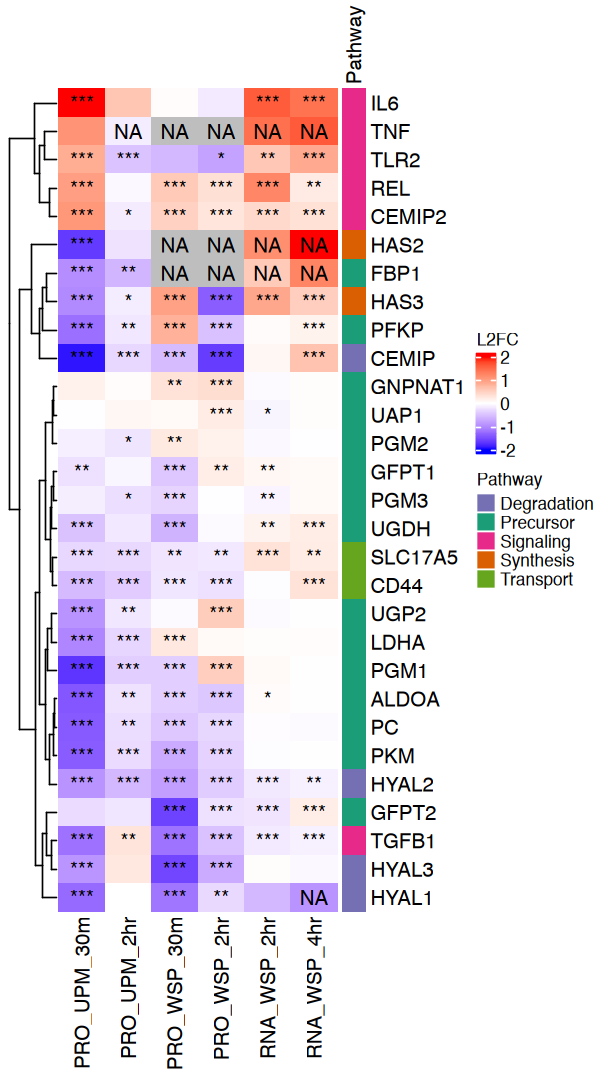

In [256]:
library(colorRamp2)

options(repr.plot.width=5, repr.plot.height=9)

Heatmap(
  mat,
  name = "L2FC",
  cluster_rows = TRUE,
  cluster_columns = FALSE,

  right_annotation = row_ha,

  show_row_names = TRUE,
  show_column_names = TRUE,

  cell_fun = function(j, i, x, y, width, height, fill) {
    if (sig_mat[i, j] != "") {
      grid.text(sig_mat[i, j], x, y, gp = gpar(fontsize = 12))
    }
  },

  col = colorRamp2(c(-2, 0, 2), c("blue", "white", "red"))
)

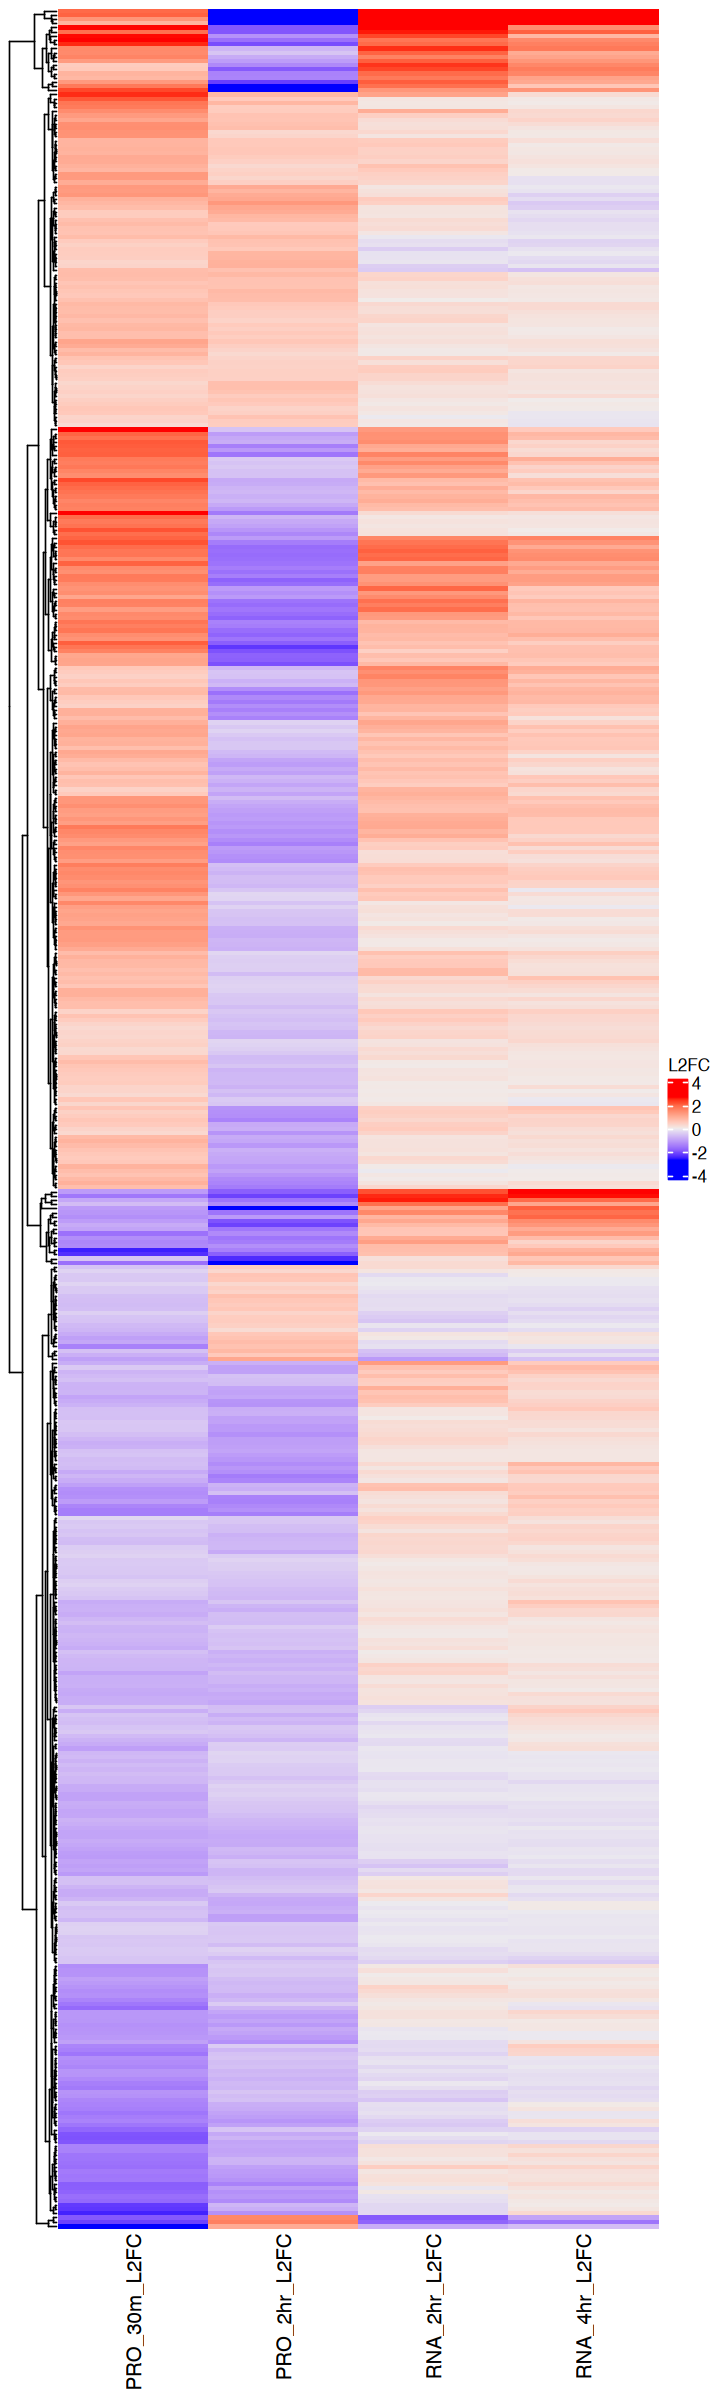

In [114]:
options(repr.plot.width=6, repr.plot.height=20)
Heatmap(as.matrix(total_all[,c("PRO_30m_L2FC", "PRO_2hr_L2FC", "RNA_2hr_L2FC", "RNA_4hr_L2FC")]), 
name="L2FC", show_row_names=FALSE, show_column_names=TRUE, cluster_rows=TRUE, cluster_columns=FALSE)

[1] 18377     4

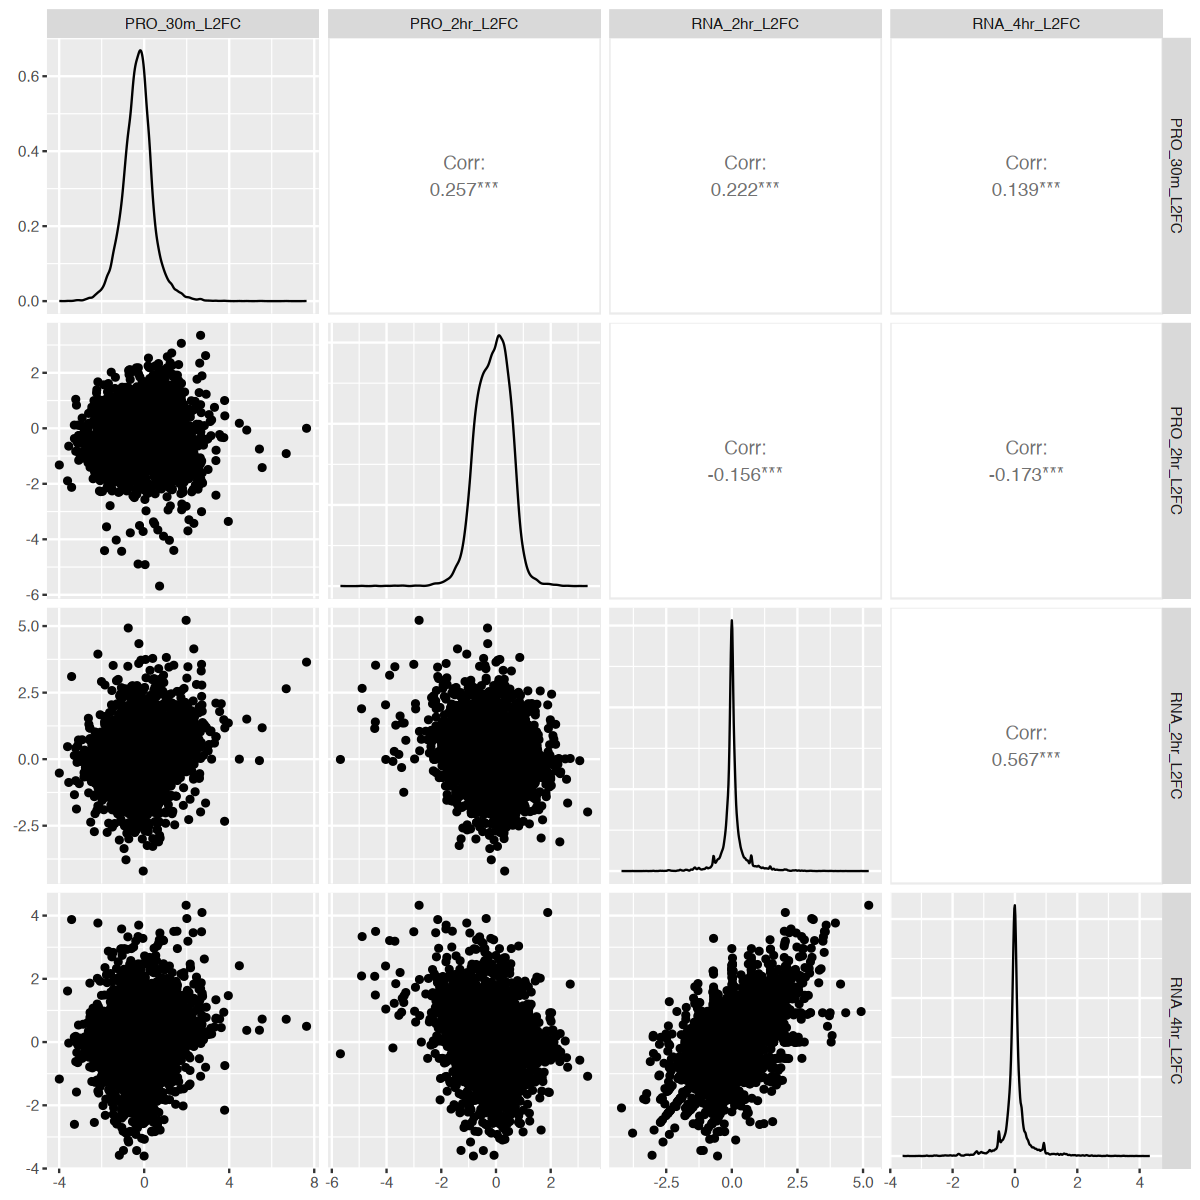

In [118]:
library(GGally)
l2fc_plot <- total_df[,c("PRO_30m_L2FC", "PRO_2hr_L2FC", "RNA_2hr_L2FC", "RNA_4hr_L2FC")]
l2fc_plot <- l2fc_plot[complete.cases(l2fc_plot),]
dim(l2fc_plot)
options(repr.plot.width=10, repr.plot.height=10)
ggpairs(l2fc_plot)

Overall, it seems like the PRO-seq 30 minutes 

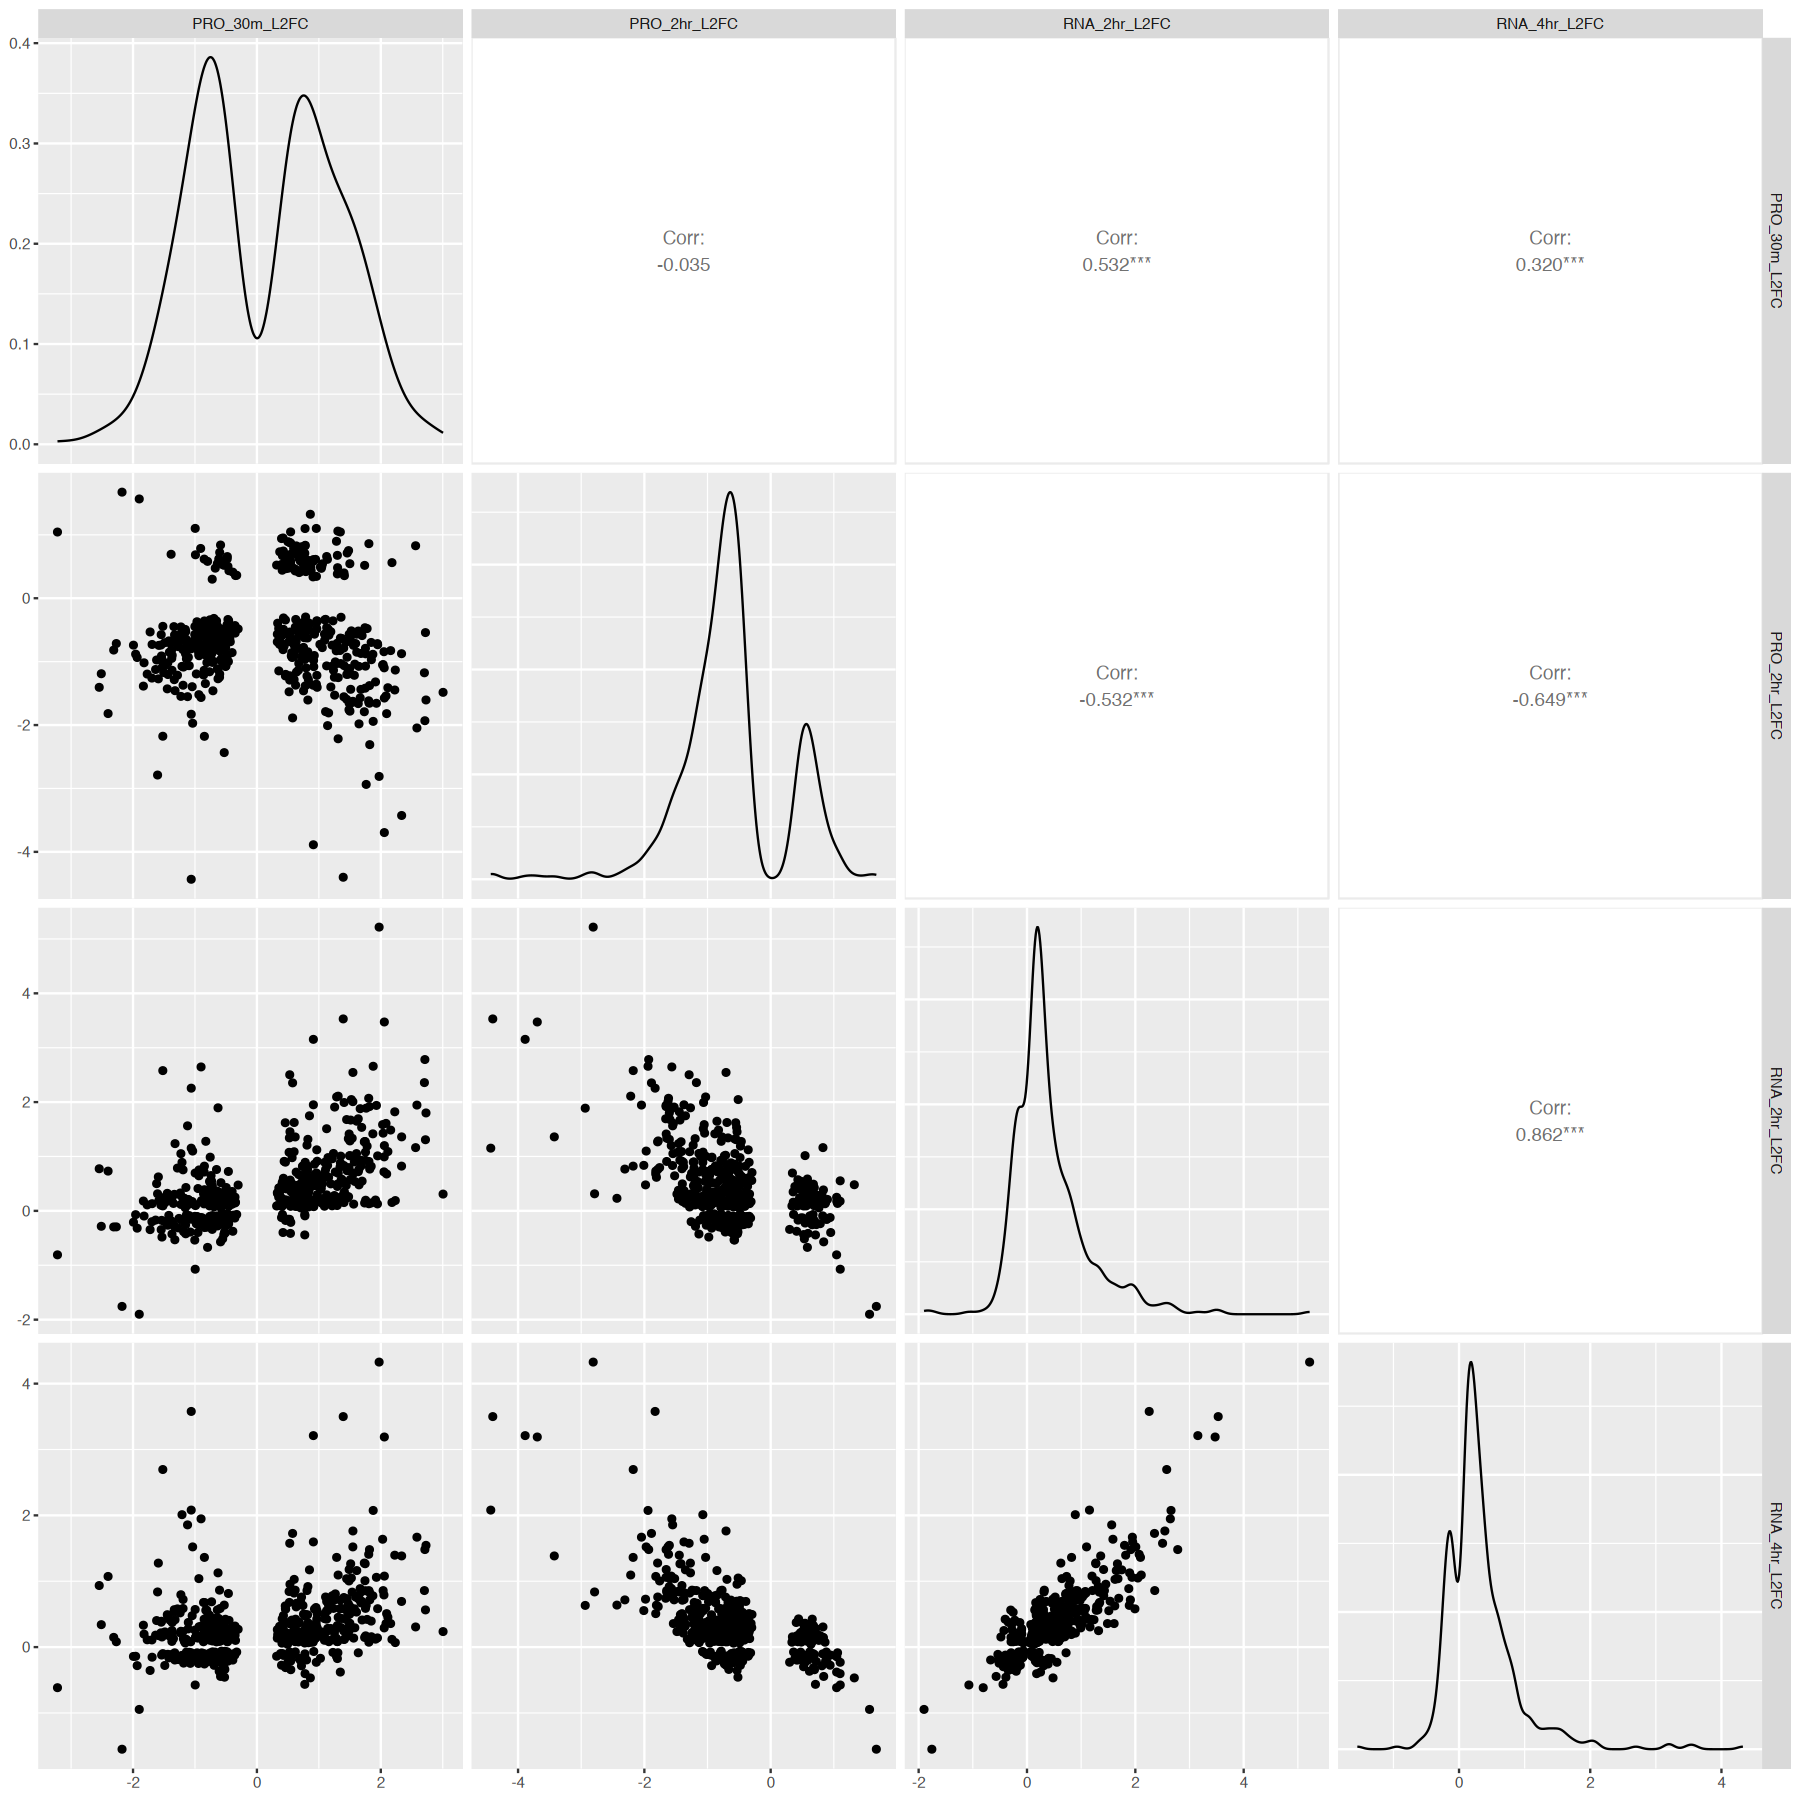

In [116]:
library(GGally)
options(repr.plot.width=15, repr.plot.height=15)
ggpairs(total_all[,c("PRO_30m_L2FC", "PRO_2hr_L2FC", "RNA_2hr_L2FC", "RNA_4hr_L2FC")])

When I only considered genes called significant in every condition:
* RNA-seq at both time points are largely well correlated (PCC=0.862)
* PRO-seq 2hr is mostly negatively correlated with most things increasing in RNA-seq decreasing in PRO-seq compared to vehicle

## Consider the strict time tables
I'm using the early, plateau, and late significant calls from before to make a cleaner picture

* Are the early genes in PRO-seq showing a continued response in RNA-seq? --> Indicates that these early genes still show a relevant thing later.
* Are the late genes in PRO-seq showing the same response in RNA-seq in directionality? 
* Are the plateau or late genes more likely to be maintained in RNA-seq?

In [126]:
get_timing_sig <- function(sig_feat) {
    # up at 30min and down by 120. Not significant for 120 vs Veh
    early_rise = setdiff(intersect(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # down at 30min and up by 120. Not significant for 120 vs Veh
    early_fall = setdiff(intersect(sig_feat[["P30_vs_Veh_down"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
	early = union(early_rise, early_fall)
    # up 120min and 30min, with no change between 120 & 30min
    plat_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P30_vs_Veh_up"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # down 120min and 30min, with no change between 120 & 30min
    plat_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P30_vs_Veh_down"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
	plat = union(plat_rise, plat_fall)
    # up at 120min compared to Veh and 30min. Not sig at 30min
    late_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    # down at 120min compared to Veh and 30min. Not sig at 30min
    late_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))

	late = union(late_rise, late_fall)
    time_sig <- list("ER"=early_rise, "EF"=early_fall, "EPR"=plat_rise, "EPF"=plat_fall, 
                     "LR"=late_rise, "LF"=late_fall, "Early"=early, "Plat"=plat, "Late"=late)
    return(time_sig)
    }

get_timing_sig_RNA <- function(sig_feat) {
    # up at 30min and down by 120. Not significant for 120 vs Veh
    early_rise = setdiff(intersect(sig_feat[["P2h_vs_Veh_up"]], sig_feat[["P4h_vs_P2h_down"]]), 
                         union(sig_feat[["P4h_vs_Veh_up"]], sig_feat[["P4h_vs_Veh_down"]]))
    # down at 30min and up by 120. Not significant for 120 vs Veh
    early_fall = setdiff(intersect(sig_feat[["P2h_vs_Veh_down"]], sig_feat[["P4h_vs_P2h_up"]]), 
                         union(sig_feat[["P4h_vs_Veh_up"]], sig_feat[["P4h_vs_Veh_down"]]))
	early = union(early_rise, early_fall)
    # up 120min and 30min, with no change between 120 & 30min
    plat_rise = setdiff(intersect(sig_feat[["P4h_vs_Veh_up"]], sig_feat[["P2h_vs_Veh_up"]]), 
                        union(sig_feat[["P4h_vs_P2h_up"]], sig_feat[["P4h_vs_P2h_down"]]))
    # down 120min and 30min, with no change between 120 & 30min
    plat_fall = setdiff(intersect(sig_feat[["P4h_vs_Veh_down"]], sig_feat[["P2h_vs_Veh_down"]]), 
                        union(sig_feat[["P4h_vs_P2h_up"]], sig_feat[["P4h_vs_P2h_down"]]))
	plat = union(plat_rise, plat_fall)
    # up at 120min compared to Veh and 30min. Not sig at 30min
    late_rise = setdiff(intersect(sig_feat[["P4h_vs_Veh_up"]], sig_feat[["P4h_vs_P30_up"]]), 
                         union(sig_feat[["P2h_vs_Veh_up"]], sig_feat[["P2h_vs_Veh_down"]]))
    # down at 120min compared to Veh and 30min. Not sig at 30min
    late_fall = setdiff(intersect(sig_feat[["P4h_vs_Veh_down"]], sig_feat[["P4h_vs_P30_down"]]), 
                         union(sig_feat[["P2h_vs_Veh_up"]], sig_feat[["P2h_vs_Veh_down"]]))

	late = union(late_rise, late_fall)
    time_sig <- list("ER"=early_rise, "EF"=early_fall, "EPR"=plat_rise, "EPF"=plat_fall, 
                     "LR"=late_rise, "LF"=late_fall, "Early"=early, "Plat"=plat, "Late"=late)
    return(time_sig)
    }

In [127]:
# read in the significance cateogires
rna_sig_genes = readRDS("../results/DESeq2/WSPRNAseq_siggenes_DESeq2_GeneHK.rds")
pro_sig_genes = readRDS("../results/DESeq2/WSP_siggenes_DESeq2_GeneHK_p1e10.rds")
# what fraction of each of the significance cateogires (based on time) are also significant in RNA-seq
## consider first just general response THEN direction too 
pro_time_sig_genes = get_timing_sig(pro_sig_genes)
rna_time_sig_genes = get_timing_sig_RNA(rna_sig_genes)

In [143]:
names(rna_sig_genes)

[1] "P4h_vs_Veh_up"   "P2h_vs_Veh_up"   "P4h_vs_P2h_up"   "P4h_vs_Veh_down"
[5] "P2h_vs_Veh_down" "P4h_vs_P2h_down"

In [147]:

rna_sig_all_genes = unique(total[total$RNA_2hr_padj < 0.05 | total$RNA_4hr_padj < 0.05,]$Gene)
rna_sig_all_genes = rna_sig_all_genes[complete.cases(rna_sig_all_genes)]
length(rna_sig_all_genes)

rna_sig_up_genes = intersect(rna_sig_genes[["P2h_vs_Veh_up"]], rna_sig_genes[["P4h_vs_Veh_up"]])
rna_sig_down_genes = intersect(rna_sig_genes[["P2h_vs_Veh_down"]], rna_sig_genes[["P4h_vs_Veh_down"]])

length(rna_sig_up_genes); length(rna_sig_down_genes); length(union(rna_sig_up_genes, rna_sig_down_genes))
length(intersect(rna_sig_up_genes, rna_sig_down_genes))


[1] 6010

[1] 1557

[1] 605

[1] 2162

[1] 0

In [189]:
# for each category, get the fraction of genes that are also significant in RNA-seq, and if so, what fraction are in the same direction
N = c(); num_sig = c(); num_sig_dir_both = c(); num_sig_dir_2h = c(); num_sig_dir_4h = c(); num_sig_time = c(); cats=c()
for (cat in c("ER", "EPR", "LR", "EF", "EPF", "LF")) {
	pro_genes = pro_time_sig_genes[[cat]]
	cats = c(cats, cat)
	# Num significant
	N = c(N, length(pro_genes))
	num_sig = c(num_sig, length(intersect(pro_genes, unlist(rna_sig_genes))))
	if (cat %in% c("ER", "EPR", "LR")) {
		# Num significant and same direction BOTH
		num_sig_dir_both = c(num_sig_dir_both, length(intersect(pro_genes, rna_sig_up_genes)))
		# Num significant and same direction for 2h
		num_sig_dir_2h = c(num_sig_dir_2h, length(intersect(pro_genes, rna_sig_genes[["P2h_vs_Veh_up"]])))
		# Num significant and same direction for 4hr
		num_sig_dir_4h = c(num_sig_dir_4h, length(intersect(pro_genes, rna_sig_genes[["P4h_vs_Veh_up"]])))
	} else if (cat %in% c("EF", "EPF", "LF")) {
		# Num significant and same direction BOTH
		num_sig_dir_both = c(num_sig_dir_both, length(intersect(pro_genes, rna_sig_down_genes)))
		# Num significant and same direction for 2h
		num_sig_dir_2h = c(num_sig_dir_2h, length(intersect(pro_genes, rna_sig_genes[["P2h_vs_Veh_down"]])))
		# Num significant and same direction for 4hr
		num_sig_dir_4h = c(num_sig_dir_4h, length(intersect(pro_genes, rna_sig_genes[["P4h_vs_Veh_down"]])))
	}	
	
}
# store in a data table
num_sig_df = data.table("Category"=cats, "N"=N,
						 "Number"=c(num_sig, num_sig_dir_both, num_sig_dir_2h, num_sig_dir_4h), 
						 "Type"=c(rep("Sig Change", 6), rep("Sig Change\nSame Dir\n(Both)", 6), rep("Sig Change\nSame Dir\n(2h)", 6), rep("Sig Change\nSame Dir\n(4h)", 6)))
#num_sig_df

# now combine the Early, Plateau, and Late Categories
for (type in unique(num_sig_df$Type)) {
	early = sum(num_sig_df[Category %in% c("ER", "EF") & Type == type,]$Number)
	early_N = sum(num_sig_df[Category %in% c("ER", "EF") & Type == type,]$N)
	plat = sum(num_sig_df[Category %in% c("EPR", "EPF") & Type == type,]$Number)
	plat_N = sum(num_sig_df[Category %in% c("EPR", "EPF") & Type == type,]$N)
	late = sum(num_sig_df[Category %in% c("LR", "LF") & Type == type,]$Number)
	late_N = sum(num_sig_df[Category %in% c("LR", "LF") & Type == type,]$N)
	num_sig_int_df = data.table("Category"=c("Early", "Plat", "Late"), "N"=c(early_N, plat_N, late_N),
						 "Number"=c(early, plat, late), 
						 "Type"=type)
	
	num_sig_df = rbind(num_sig_df, num_sig_int_df)
	}
num_sig_df$Value <- num_sig_df$Number / num_sig_df$N
num_sig_df

Category,N,Number,Type,Value
<chr>,<int>,<int>,<chr>,<dbl>
ER,416,328,Sig Change,0.788461538
EPR,164,118,Sig Change,0.719512195
LR,879,455,Sig Change,0.517633675
EF,1527,732,Sig Change,0.479371316
EPF,1148,533,Sig Change,0.464285714
LF,549,339,Sig Change,0.617486339
ER,416,236,Sig Change Same Dir (Both),0.567307692
EPR,164,30,Sig Change Same Dir (Both),0.182926829
LR,879,38,Sig Change Same Dir (Both),0.043230944


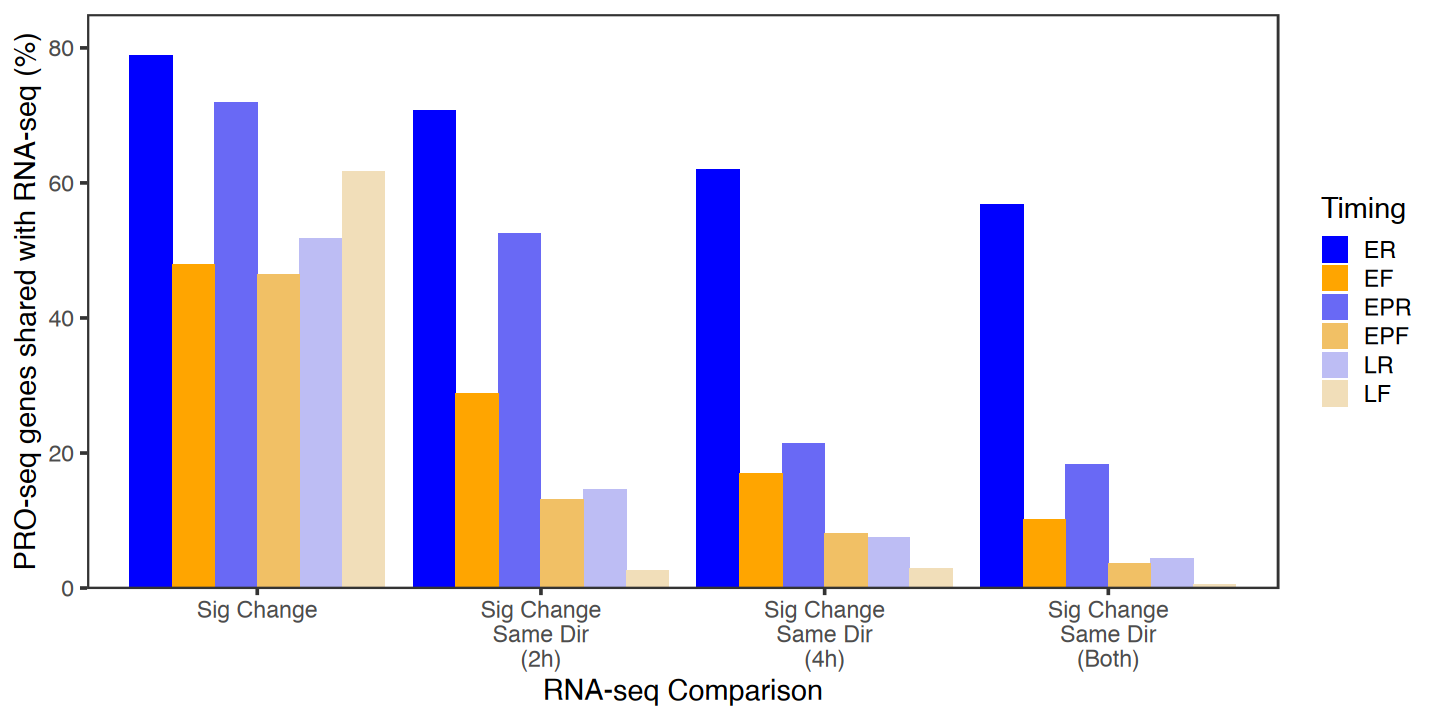

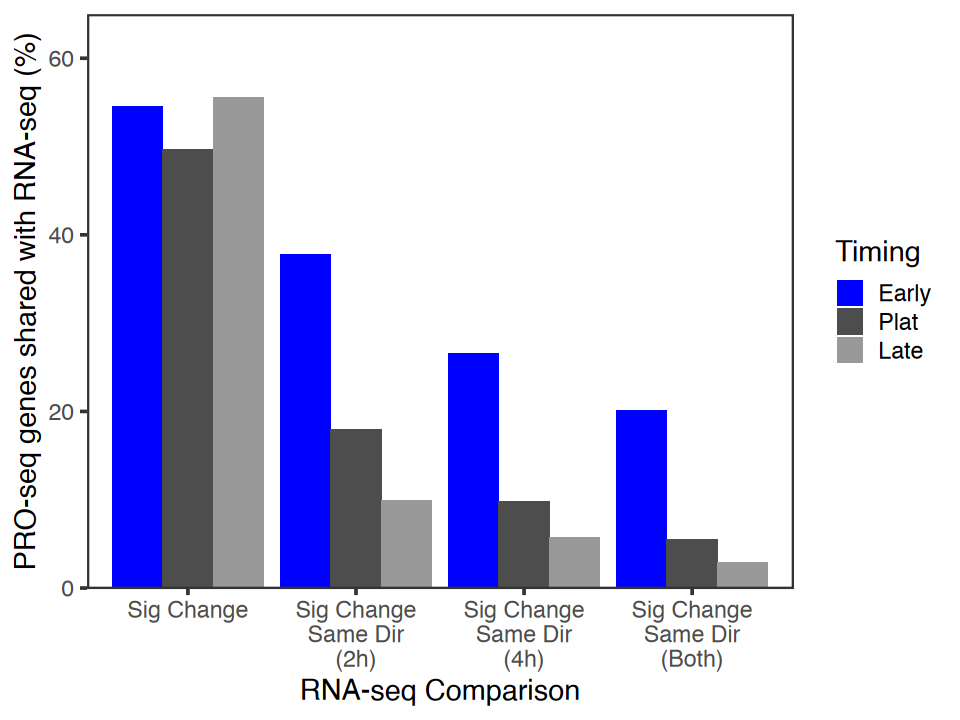

In [206]:
time_colors=c("ER"="blue1", "EF"="orange1", "EPR"="#6969f5", "EPF"="#f1c065", "LR"="#bdbdf4", "LF"="#f1deb9")
 
options(repr.plot.width=12, repr.plot.height=6)
ggplot(num_sig_df[num_sig_df$Category %in% c("ER", "EF", "EPR", "EPF", "LR", "LF")], aes(x=Type, y=Value*100, fill=factor(Category, levels=c("ER", "EF", "EPR", "EPF", "LR", "LF")))) + 
geom_bar(stat="identity", position=position_dodge()) + theme_bw(base_size=17)  + labs(fill="Timing", y="PRO-seq genes shared with RNA-seq (%)", x="RNA-seq Comparison") + 
scale_fill_manual(values=time_colors) + scale_y_continuous(limits = c(0, 85), expand=c(0, 0)) + theme(panel.grid = element_blank())
time_colors=c("Early"="blue1", "Plat"="grey30",  "Late"="grey60")

options(repr.plot.width=8, repr.plot.height=6)
# Early N=1943 (416 and 1527), Plat N=1312 (164 and 1148), Late N=1428 (879 & 548)
ggplot(num_sig_df[num_sig_df$Category %in% c("Early", "Plat", "Late")], aes(x=Type, y=Value*100, fill=factor(Category, levels=c("Early", "Plat", "Late")))) + 
geom_bar(stat="identity", position=position_dodge()) + theme_bw(base_size=17)  + labs(fill="Timing", y="PRO-seq genes shared with RNA-seq (%)", x="RNA-seq Comparison") + 
scale_fill_manual(values=time_colors) + scale_y_continuous(limits = c(0, 65), expand=c(0, 0)) + theme(panel.grid = element_blank())
